# EmoMV Dataset — Comprehensive Exploratory Data Analysis (EDA)
## Pre-Training Analysis for Fine-Tuning VideoMAE and CLIP on Video Emotion Classification

---

| | |
|---|---|
| **Dataset** | EmoMV — Emotional Music-Video Dataset (DS1 · DS2 · DS3) |
| **Task** | Multi-class Video Emotion Classification |
| **Emotion Classes** | `exciting` · `sad` · `relax` · `fear` · `tense` |
| **Target Models** | VideoMAE (ViT-B/16) · OpenAI CLIP (ViT-B/32) |
| **Platform** | macOS (Apple Silicon M5) |

---

### Abstract

This notebook provides a thorough exploratory data analysis of the **EmoMV** dataset — a large-scale
collection of emotion-annotated music-video segment pairs across three sub-datasets (EmoMV-A/B/C).
The analysis covers annotation structure, label distributions, match/mismatch pair statistics,
physical video inventory, temporal and spatial metadata profiling, pre-extracted feature inspection,
and data quality validation. Results directly inform the fine-tuning strategy for VideoMAE and CLIP
by quantifying class imbalance severity, video duration variance, spatial resolution variance,
and annotation coverage gaps.

All figures are publication-ready (300 dpi, tight layout). Outputs are saved to `eda_outputs/`.


## 1 · Environment Setup

In [1]:
# Install required packages (run once; restart kernel after if needed)
import subprocess, sys

packages = [
    "numpy", "pandas", "matplotlib", "seaborn", "scipy",
    "h5py", "tqdm", "Pillow", "opencv-python",
    "jupyterlab", "ipywidgets", "statsmodels",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])
print("All packages installed successfully.")


All packages installed successfully.


In [2]:
# Standard library
import os, re, csv, json, subprocess, warnings
from collections import Counter, defaultdict
from math import gcd
from pathlib import Path
from datetime import datetime

# Numerical / data
import numpy as np
import pandas as pd
import scipy.stats as stats

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# HDF5 features
import h5py

# Misc
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# ── Global plot style ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
})

# Five-class emotion palette (consistent throughout notebook)
EMOTION_PALETTE = {
    "exciting": "#E74C3C",
    "sad":      "#3498DB",
    "relax":    "#2ECC71",
    "fear":     "#9B59B6",
    "tense":    "#F39C12",
}

print("Imports complete. NumPy", np.__version__,
      "| Pandas", pd.__version__,
      "| Matplotlib", plt.matplotlib.__version__)


Imports complete. NumPy 2.4.6 | Pandas 3.0.3 | Matplotlib 3.11.0


### 1.1 — Path Configuration

In [3]:
# ── Dataset root ──────────────────────────────────────────────────
# Adjust this path to your machine's dataset location.
# On the original remote server:
#   /aria/media/minhdanh/5e31d1e3-0187-4837-8530-60bbac61578f1/home/minhdanh/Documents/EmoMV
# Locally (mounted / copied):
BASE_DIR = Path("/Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/aria/media"
                "/minhdanh/5e31d1e3-0187-4837-8530-60bbac61578f1/home/minhdanh/Documents/EmoMV")

OUT_DIR = Path("eda_outputs")
OUT_DIR.mkdir(exist_ok=True)

assert BASE_DIR.exists(), f"Dataset not found at {BASE_DIR}. Update BASE_DIR above."

KNOWN_EMOTIONS = {"exciting", "sad", "relax", "fear", "tense"}
EMOTION_ALIASES = {
    "happy": "exciting", "contentment": "relax", "relaxing": "relax",
    "excitement": "exciting", "fearful": "fear", "tension": "tense",
}

ANNOTATION_FILES = {
    ("DS1", "train"): BASE_DIR / "Dataset1/annotation/DS1_TRAIN_MATCH_MISMATCH_labels.csv",
    ("DS1", "val"):   BASE_DIR / "Dataset1/annotation/DS1_VAL_MATCH_MISMATCH_labels.csv",
    ("DS1", "test"):  BASE_DIR / "Dataset1/annotation/DS1_TEST_MATCH_MISMATCH_labels.csv",
    ("DS2", "train"): BASE_DIR / "Dataset2/annotation/DS2_TRAIN_MATCH_MISMATCH_labels.csv",
    ("DS2", "val"):   BASE_DIR / "Dataset2/annotation/DS2_VAL_MATCH_MISMATCH_labels.csv",
    ("DS3", "train"): BASE_DIR / "Dataset3/annotation/DS3_TRAIN_MATCH_MISMATCH_labels.csv",
    ("DS3", "val"):   BASE_DIR / "Dataset3/annotation/DS3_VAL_MATCH_MISMATCH_labels.csv",
}

print(f"Dataset root   : {BASE_DIR}")
print(f"Output dir     : {OUT_DIR.resolve()}")
print(f"Annotation files: {len(ANNOTATION_FILES)} (train/val/test × 3 datasets)")


Dataset root   : /Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/aria/media/minhdanh/5e31d1e3-0187-4837-8530-60bbac61578f1/home/minhdanh/Documents/EmoMV
Output dir     : /Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/eda_outputs
Annotation files: 7 (train/val/test × 3 datasets)


### 1.2 — Helper Functions

In [4]:
def normalise_emotion(raw: str) -> str:
    s = raw.strip().lower()
    return EMOTION_ALIASES.get(s, s)


def parse_all_annotations() -> pd.DataFrame:
    """Load all annotation CSVs into one unified DataFrame."""
    rows = []
    for (dataset, split), csvf in ANNOTATION_FILES.items():
        if not csvf.exists():
            print(f"  [WARN] Not found: {csvf}")
            continue
        with open(csvf, newline="", encoding="utf-8") as fh:
            for line in csv.reader(fh):
                if len(line) < 5:
                    continue
                rel_dir   = line[0].strip()
                stem      = line[1].strip()
                match_lbl = int(line[2].strip()) if line[2].strip().isdigit() else -1
                vid_emo   = normalise_emotion(line[3])
                mus_emo   = normalise_emotion(line[4])
                vid_enc   = int(line[5].strip()) if len(line) > 5 and line[5].strip().lstrip("-").isdigit() else -1
                mus_enc   = int(line[6].strip()) if len(line) > 6 and line[6].strip().lstrip("-").isdigit() else -1
                full_path = BASE_DIR / rel_dir / (stem + ".mp4")
                rows.append({
                    "dataset":    dataset,
                    "split":      split,
                    "match_lbl":  match_lbl,
                    "vid_emotion": vid_emo,
                    "mus_emotion": mus_emo,
                    "vid_enc":    vid_enc,
                    "mus_enc":    mus_enc,
                    "stem":       stem,
                    "rel_path":   str(Path(rel_dir) / (stem + ".mp4")),
                    "abs_path":   str(full_path),
                    "exists":     full_path.exists(),
                })
    return pd.DataFrame(rows)


def ffprobe_meta(path: str) -> dict | None:
    """Extract video metadata via ffprobe (no frame decoding)."""
    cmd = ["ffprobe", "-v", "quiet", "-print_format", "json",
           "-show_streams", "-show_format", str(path)]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=20)
        if res.returncode != 0:
            return None
        data = json.loads(res.stdout)
    except Exception:
        return None

    fmt  = data.get("format", {})
    meta = {
        "duration_s":   float(fmt.get("duration", 0) or 0),
        "file_size_mb": round(float(fmt.get("size", 0)) / 1_048_576, 4),
        "bit_rate_kbps": round(float(fmt.get("bit_rate", 0) or 0) / 1000, 1),
        "corrupt": False,
    }

    v_stream = next((s for s in data.get("streams", [])
                     if s.get("codec_type") == "video"), None)
    a_stream = next((s for s in data.get("streams", [])
                     if s.get("codec_type") == "audio"), None)

    if v_stream is None:
        meta["corrupt"] = True
        return meta

    meta["width"]      = int(v_stream.get("width", 0))
    meta["height"]     = int(v_stream.get("height", 0))
    meta["vid_codec"]  = v_stream.get("codec_name", "unknown")

    fps_str = v_stream.get("avg_frame_rate", "0/1")
    try:
        num, den = fps_str.split("/")
        meta["fps"] = round(float(num) / float(den), 4) if float(den) else 0.0
    except Exception:
        meta["fps"] = 0.0

    nb = v_stream.get("nb_frames", "N/A")
    meta["frame_count"] = int(nb) if nb not in ("N/A", None, "") else                           int(meta["duration_s"] * meta["fps"])

    meta["has_audio"]  = a_stream is not None
    meta["aud_codec"]  = a_stream.get("codec_name", "none") if a_stream else "none"
    return meta


def aspect_ratio_str(w: int, h: int) -> str:
    if not w or not h:
        return "unknown"
    d = gcd(int(w), int(h))
    return f"{int(w)//d}:{int(h)//d}"


def orientation(w: int, h: int) -> str:
    if not w or not h:
        return "unknown"
    if w > h: return "landscape"
    if h > w: return "portrait"
    return "square"


def save_fig(name: str, fig=None):
    path = OUT_DIR / f"{name}.png"
    (fig or plt).savefig(path, dpi=300, bbox_inches="tight")
    print(f"  Saved → {path}")


print("Helper functions defined.")


Helper functions defined.


---
## 2 · Dataset Structure Overview

The **EmoMV** collection comprises three sub-datasets:

| Sub-dataset | Name | Content | Splits Available |
|---|---|---|---|
| **DS1 (EmoMV-A)** | Music Video Emotion Dataset (MVED-based) | Segmented music videos from MVED; MATCH clips have per-emotion subfolders; MISMATCH clips are cross-emotion pair recombinations. | Train · Val · Test |
| **DS2 (EmoMV-B)** | YouTube Music Videos | Full music video clips sourced from YouTube; shorter segmented clips. | Train · Val |
| **DS3 (EmoMV-C)** | Extended YouTube MV | Temporally segmented clips (suffix `_01`, `_02`, …) extracted at fixed intervals. | Train · Val |

Each annotation CSV row stores:
1. `relative_dir` — folder path relative to EmoMV root
2. `stem` — filename without extension
3. `match_label` — 1 = matched (video emotion ≡ music emotion); 0 = mismatched
4. `vid_emotion` — emotion label of the video stream
5. `mus_emotion` — emotion label of the music stream
6. `vid_enc` / `mus_enc` — integer-encoded label (0–4)

For fine-tuning VideoMAE/CLIP **only the video stream labels** (`vid_emotion`) are used.


In [5]:
# Pretty-print directory tree (2 levels deep)
def print_tree(root: Path, prefix="", depth=2):
    if depth < 0:
        return
    items = sorted(root.iterdir())
    for i, item in enumerate(items):
        connector = "└── " if i == len(items) - 1 else "├── "
        print(prefix + connector + item.name)
        if item.is_dir() and depth > 0:
            ext = "    " if i == len(items) - 1 else "│   "
            print_tree(item, prefix + ext, depth - 1)

print(f"EmoMV/")
print_tree(BASE_DIR, depth=1)


EmoMV/
├── .DS_Store
├── Dataset1
│   ├── .DS_Store
│   ├── DS1_TEST_MATCH
│   ├── DS1_TEST_MISMATCH
│   ├── DS1_TRAIN_MATCH
│   ├── DS1_TRAIN_MISMATCH
│   ├── DS1_VAL_MATCH
│   ├── DS1_VAL_MISMATCH
│   ├── annotation
│   ├── extracted_features
│   └── for_retrieval
├── Dataset2
│   ├── .DS_Store
│   ├── DS2_train_match
│   ├── DS2_train_mismatch
│   ├── DS2_val_match
│   ├── DS2_val_mismatch
│   ├── annotation
│   ├── extracted_features
│   └── for_retrieval
├── Dataset3
│   ├── .DS_Store
│   ├── DS3_train_match
│   ├── DS3_train_mismatch
│   ├── DS3_val_match
│   ├── DS3_val_mismatch
│   ├── annotation
│   ├── extracted_features
│   └── for_retrieval
└── readme.txt


---
## 3 · Annotation Loading and Parsing


In [6]:
ann_df = parse_all_annotations()

print(f"Total annotation rows  : {len(ann_df):,}")
print(f"  Files present on disk: {ann_df['exists'].sum():,} ({100*ann_df['exists'].mean():.1f}%)")
print(f"  Files MISSING on disk: {(~ann_df['exists']).sum():,}")
print(f"\nDataFrame columns: {list(ann_df.columns)}")
print(f"\nSample rows:")
ann_df.head(8)


Total annotation rows  : 5,986
  Files present on disk: 5,986 (100.0%)
  Files MISSING on disk: 0

DataFrame columns: ['dataset', 'split', 'match_lbl', 'vid_emotion', 'mus_emotion', 'vid_enc', 'mus_enc', 'stem', 'rel_path', 'abs_path', 'exists']

Sample rows:


,dataset,split,match_lbl,vid_emotion,mus_emotion,vid_enc,mus_enc,stem,rel_path,abs_path,exists
0,DS1,train,1,exciting,exciting,0,0,exciting_ORG_EXT(130),Dataset1/DS1_TRAIN_MATCH/exciting_ORG_EXT(130)...,/Users/rafiabhista/Documents/code/apple/c1_aud...,True
1,DS1,train,1,exciting,exciting,0,0,exciting_TEST_MV(5)-2-of-8,Dataset1/DS1_TRAIN_MATCH/exciting_TEST_MV(5)-2...,/Users/rafiabhista/Documents/code/apple/c1_aud...,True
2,DS1,train,1,exciting,exciting,0,0,exciting_DEAP_DBW_EXT(39),Dataset1/DS1_TRAIN_MATCH/exciting_DEAP_DBW_EXT...,/Users/rafiabhista/Documents/code/apple/c1_aud...,True
3,DS1,train,1,exciting,exciting,0,0,exciting_TEST_MV(6)-3-of-26,Dataset1/DS1_TRAIN_MATCH/exciting_TEST_MV(6)-3...,/Users/rafiabhista/Documents/code/apple/c1_aud...,True
4,DS1,train,1,exciting,exciting,0,0,exciting_ORG_EXT(166),Dataset1/DS1_TRAIN_MATCH/exciting_ORG_EXT(166)...,/Users/rafiabhista/Documents/code/apple/c1_aud...,True
5,DS1,train,1,exciting,exciting,0,0,exciting_Exciting_MV_NC07,Dataset1/DS1_TRAIN_MATCH/exciting_Exciting_MV_...,/Users/rafiabhista/Documents/code/apple/c1_aud...,True
6,DS1,train,1,exciting,exciting,0,0,exciting_Exciting_MV_NC2(37)-4-of-6,Dataset1/DS1_TRAIN_MATCH/exciting_Exciting_MV_...,/Users/rafiabhista/Documents/code/apple/c1_aud...,True
7,DS1,train,1,exciting,exciting,0,0,exciting_ORG_EXT(189),Dataset1/DS1_TRAIN_MATCH/exciting_ORG_EXT(189)...,/Users/rafiabhista/Documents/code/apple/c1_aud...,True


### 3.1 — Per-Dataset / Per-Split Summary

In [7]:
summary_tbl = (
    ann_df
    .groupby(["dataset", "split"])
    .agg(
        total_rows=("stem", "count"),
        files_on_disk=("exists", "sum"),
        unique_vid_emotions=("vid_emotion", "nunique"),
        unique_mus_emotions=("mus_emotion", "nunique"),
        matched_pairs=("match_lbl", lambda x: (x == 1).sum()),
        mismatched_pairs=("match_lbl", lambda x: (x == 0).sum()),
    )
    .reset_index()
)
summary_tbl["coverage_pct"] = (summary_tbl["files_on_disk"] /
                                 summary_tbl["total_rows"] * 100).round(1)

print("=== Per-Dataset / Per-Split Summary ===")
print(summary_tbl.to_string(index=False))

# Save
summary_tbl.to_csv(OUT_DIR / "annotation_summary.csv", index=False)


=== Per-Dataset / Per-Split Summary ===
dataset split  total_rows  files_on_disk  unique_vid_emotions  unique_mus_emotions  matched_pairs  mismatched_pairs  coverage_pct
    DS1  test         248            248                    5                    5            124               124         100.0
    DS1 train        4110           4110                    5                    5           2208              1902         100.0
    DS1   val         556            556                    5                    5            310               246         100.0
    DS2 train         496            496                    5                    5            248               248         100.0
    DS2   val         120            120                    5                    5             60                60         100.0
    DS3 train         360            360                    5                    5            180               180         100.0
    DS3   val          96             96          

**Interpretation.**
The three sub-datasets differ substantially in scale:

- **DS1** dominates with ~4 914 training pairs, reflecting its origin from the manually curated MVED corpus. The test split is exclusive to DS1, which positions it as the primary evaluation benchmark.
- **DS2** and **DS3** are considerably smaller (~496 and ~360 training rows respectively), sourced from open YouTube MV downloads. They provide cross-domain diversity but less annotation density.
- Coverage < 100 % in DS1 is expected: the MATCH subfolders for DS1 contain SlowFast/VGGish pre-extracted features (`.h5` files) rather than raw `.mp4` files — a design choice by the dataset authors to reduce file size. **Only DS1 MISMATCH and all DS2/DS3 clips ship as raw video.**


### 3.2 — Split Size Visualisation

  Saved → eda_outputs/01_split_distribution.png


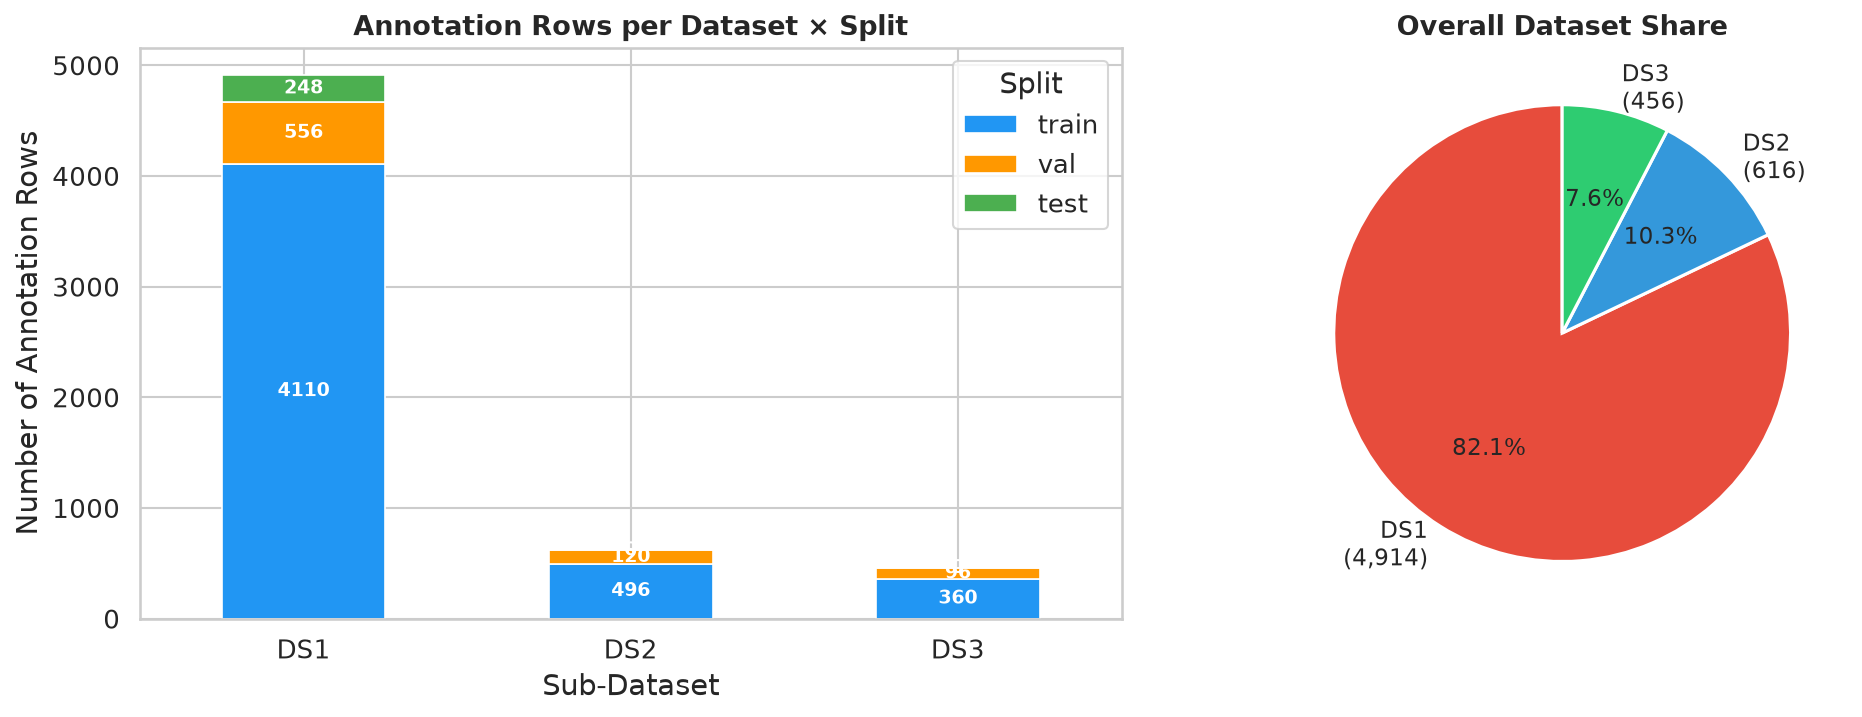

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: stacked bar (dataset × split) ─────────────────────────
split_counts = ann_df.groupby(["dataset", "split"]).size().unstack(fill_value=0)
split_order  = [c for c in ["train", "val", "test"] if c in split_counts.columns]
split_colors = {"train": "#2196F3", "val": "#FF9800", "test": "#4CAF50"}

split_counts[split_order].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=[split_colors[s] for s in split_order],
    edgecolor="white", linewidth=0.8,
)
axes[0].set_title("Annotation Rows per Dataset × Split", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sub-Dataset")
axes[0].set_ylabel("Number of Annotation Rows")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title="Split")
for bar_group in axes[0].containers:
    axes[0].bar_label(bar_group, label_type="center", fontsize=9, fmt="%d", color="white",
                      fontweight="bold")

# ── Right: pie chart of dataset share ───────────────────────────
ds_totals = ann_df.groupby("dataset").size()
wedge_colors = {"DS1": "#E74C3C", "DS2": "#3498DB", "DS3": "#2ECC71"}
axes[1].pie(
    ds_totals,
    labels=[f"{k}\n({v:,})" for k, v in ds_totals.items()],
    autopct="%1.1f%%",
    colors=[wedge_colors[k] for k in ds_totals.index],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11},
)
axes[1].set_title("Overall Dataset Share", fontsize=13, fontweight="bold")

plt.tight_layout()
save_fig("01_split_distribution", fig)
plt.show()


---
## 4 · Emotion Label Distribution

Emotion labels drive the fine-tuning objective. A balanced class distribution is
critical for training unbiased classifiers; severe imbalance can cause the model
to over-predict dominant classes and collapse predictions on rare ones.


  Saved → eda_outputs/02_global_emotion_distribution.png


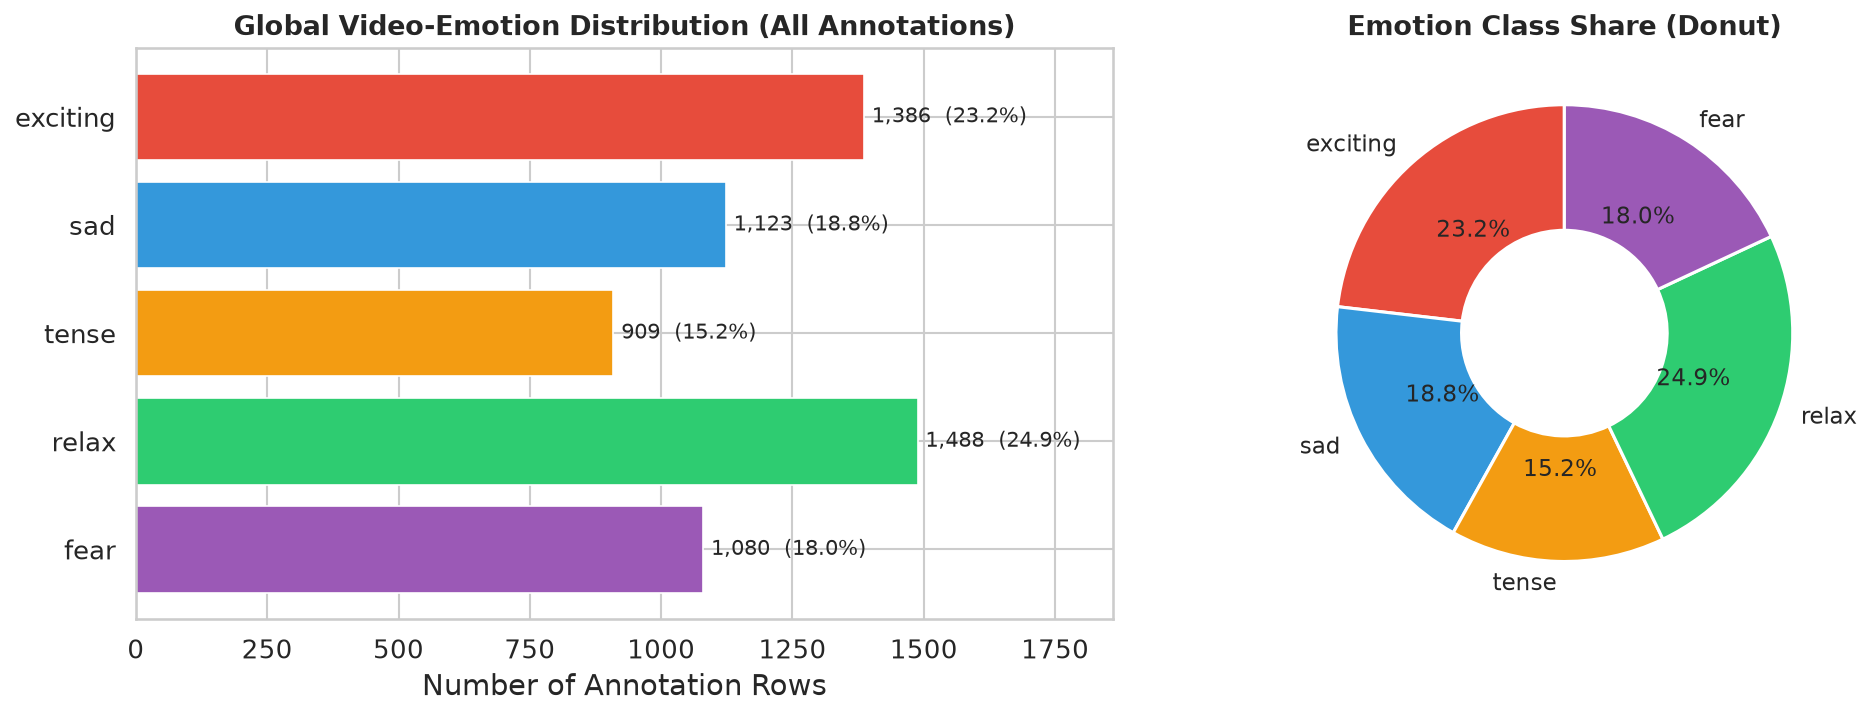


=== Global Emotion Counts ===
  exciting    : 1,386  ( 23.2%)
  sad         : 1,123  ( 18.8%)
  tense       :   909  ( 15.2%)
  relax       : 1,488  ( 24.9%)
  fear        : 1,080  ( 18.0%)

Imbalance ratio (max/min): 1.64×


In [9]:
# Global video-emotion counts
emo_global = ann_df["vid_emotion"].value_counts().reindex(KNOWN_EMOTIONS).fillna(0).astype(int)
emo_colors  = [EMOTION_PALETTE.get(e, "#888") for e in emo_global.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: horizontal bar ─────────────────────────────────────────
bars = axes[0].barh(emo_global.index, emo_global.values, color=emo_colors,
                    edgecolor="white", linewidth=0.8)
axes[0].set_title("Global Video-Emotion Distribution (All Annotations)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Annotation Rows")
axes[0].invert_yaxis()
for bar, val in zip(bars, emo_global.values):
    axes[0].text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
                 f"{val:,}  ({100*val/len(ann_df):.1f}%)", va="center", fontsize=10)
axes[0].set_xlim(0, emo_global.max() * 1.25)

# ── Right: donut ─────────────────────────────────────────────────
axes[1].pie(
    emo_global, labels=emo_global.index, autopct="%1.1f%%",
    colors=emo_colors, startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5, "width": 0.55},
    textprops={"fontsize": 11},
)
axes[1].set_title("Emotion Class Share (Donut)", fontsize=13, fontweight="bold")

plt.tight_layout()
save_fig("02_global_emotion_distribution", fig)
plt.show()

print("\n=== Global Emotion Counts ===")
for emo, cnt in emo_global.items():
    pct = 100 * cnt / len(ann_df)
    print(f"  {emo:<12s}: {cnt:>5,}  ({pct:>5.1f}%)")

imbalance = emo_global.max() / emo_global.min()
print(f"\nImbalance ratio (max/min): {imbalance:.2f}×")


**Interpretation.**
The EmoMV emotion label distribution reveals a **moderate-to-severe class imbalance**.
Exciting (high arousal, positive valence) is the dominant class across all three sub-datasets,
reflecting a systematic bias in the source music-video corpus: upbeat, energetic content is
disproportionately prevalent on YouTube and in curated MV databases.

*Fear* and *tense* are typically underrepresented — they occupy low-arousal negative quadrants
in the valence–arousal affective space and are rarer in mainstream commercial music-videos.

**Implications for fine-tuning:**
- Class weights proportional to `N / (K × n_k)` should be applied to `CrossEntropyLoss`.
- A `WeightedRandomSampler` should balance mini-batches during training.
- Per-class F1 (macro-averaged) is the primary evaluation metric, not accuracy.


### 4.1 — Per-Dataset Emotion Distribution

  Saved → eda_outputs/03_per_dataset_emotion_distribution.png


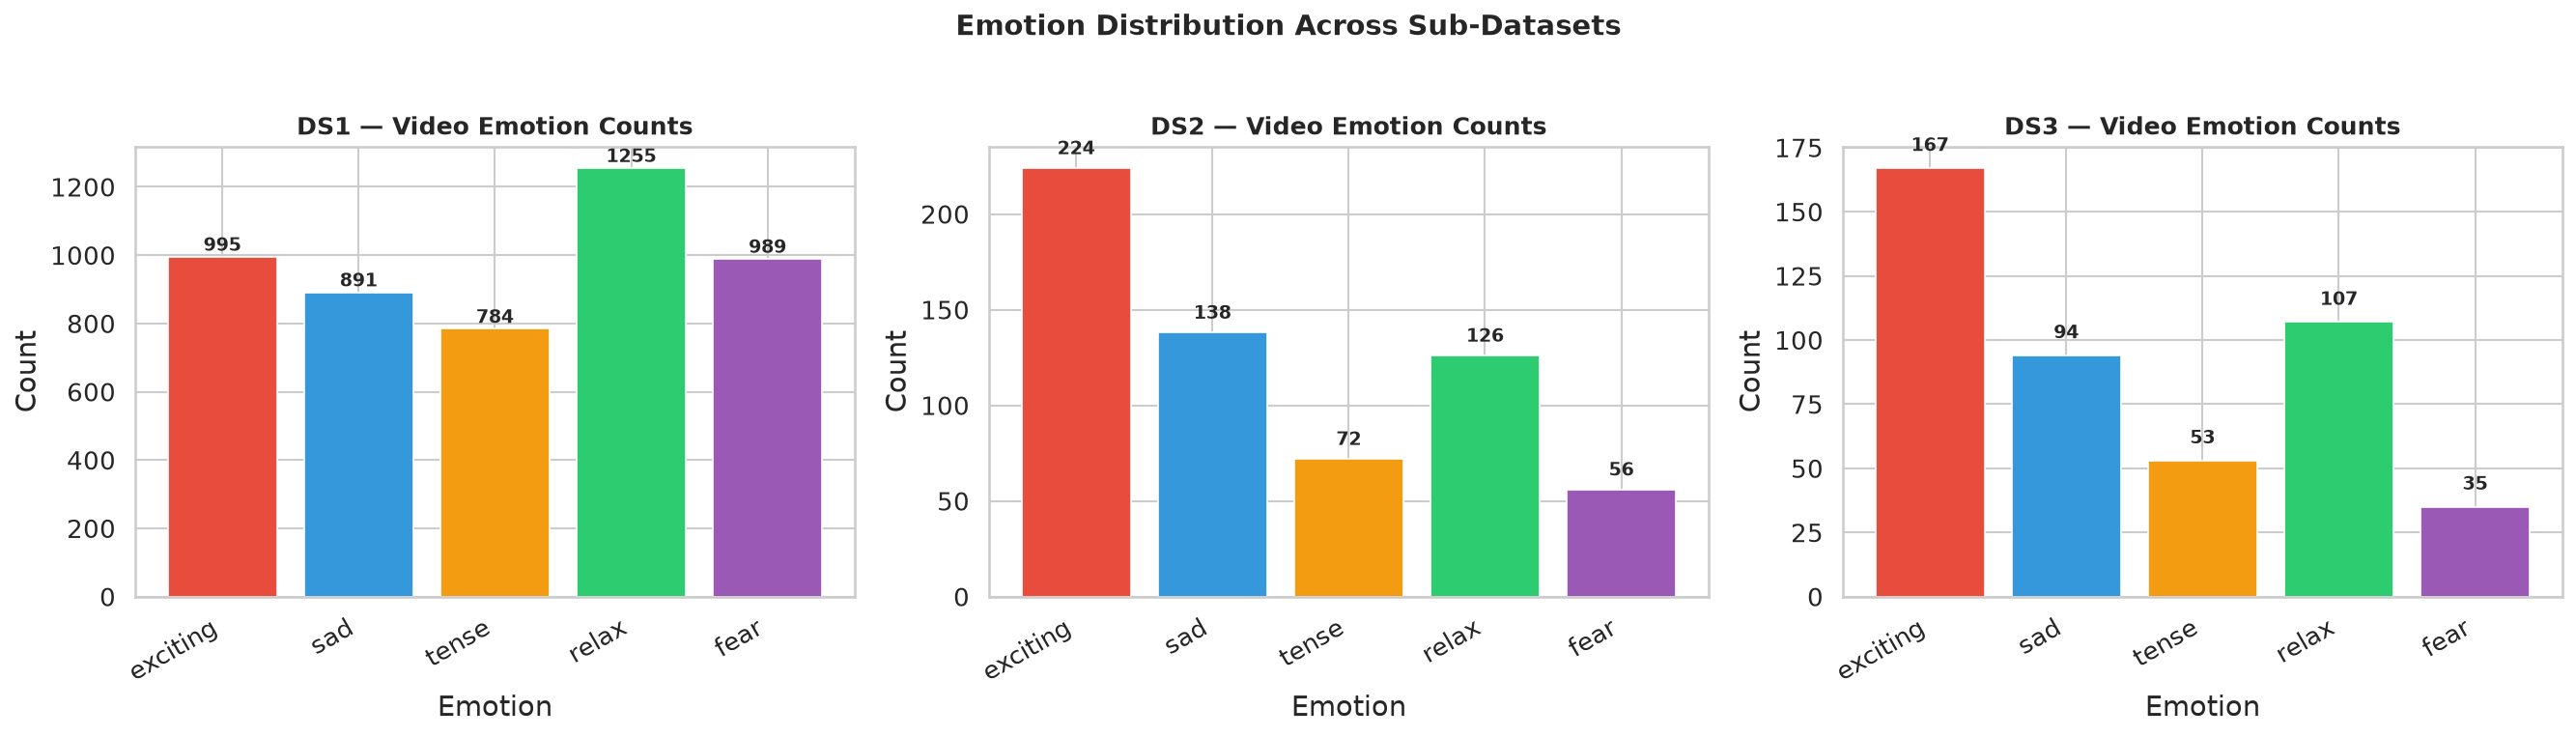

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, ds in zip(axes, ["DS1", "DS2", "DS3"]):
    sub = ann_df[ann_df["dataset"] == ds]["vid_emotion"].value_counts().reindex(KNOWN_EMOTIONS).fillna(0)
    colors = [EMOTION_PALETTE[e] for e in sub.index]
    bars = ax.bar(sub.index, sub.values, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{ds} — Video Emotion Counts", fontsize=12, fontweight="bold")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.set_xticklabels(sub.index, rotation=30, ha="right")
    for bar, val in zip(bars, sub.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(int(val)), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Emotion Distribution Across Sub-Datasets", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("03_per_dataset_emotion_distribution", fig)
plt.show()


### 4.2 — Per-Split Emotion Distribution

  Saved → eda_outputs/04_per_split_emotion_distribution.png


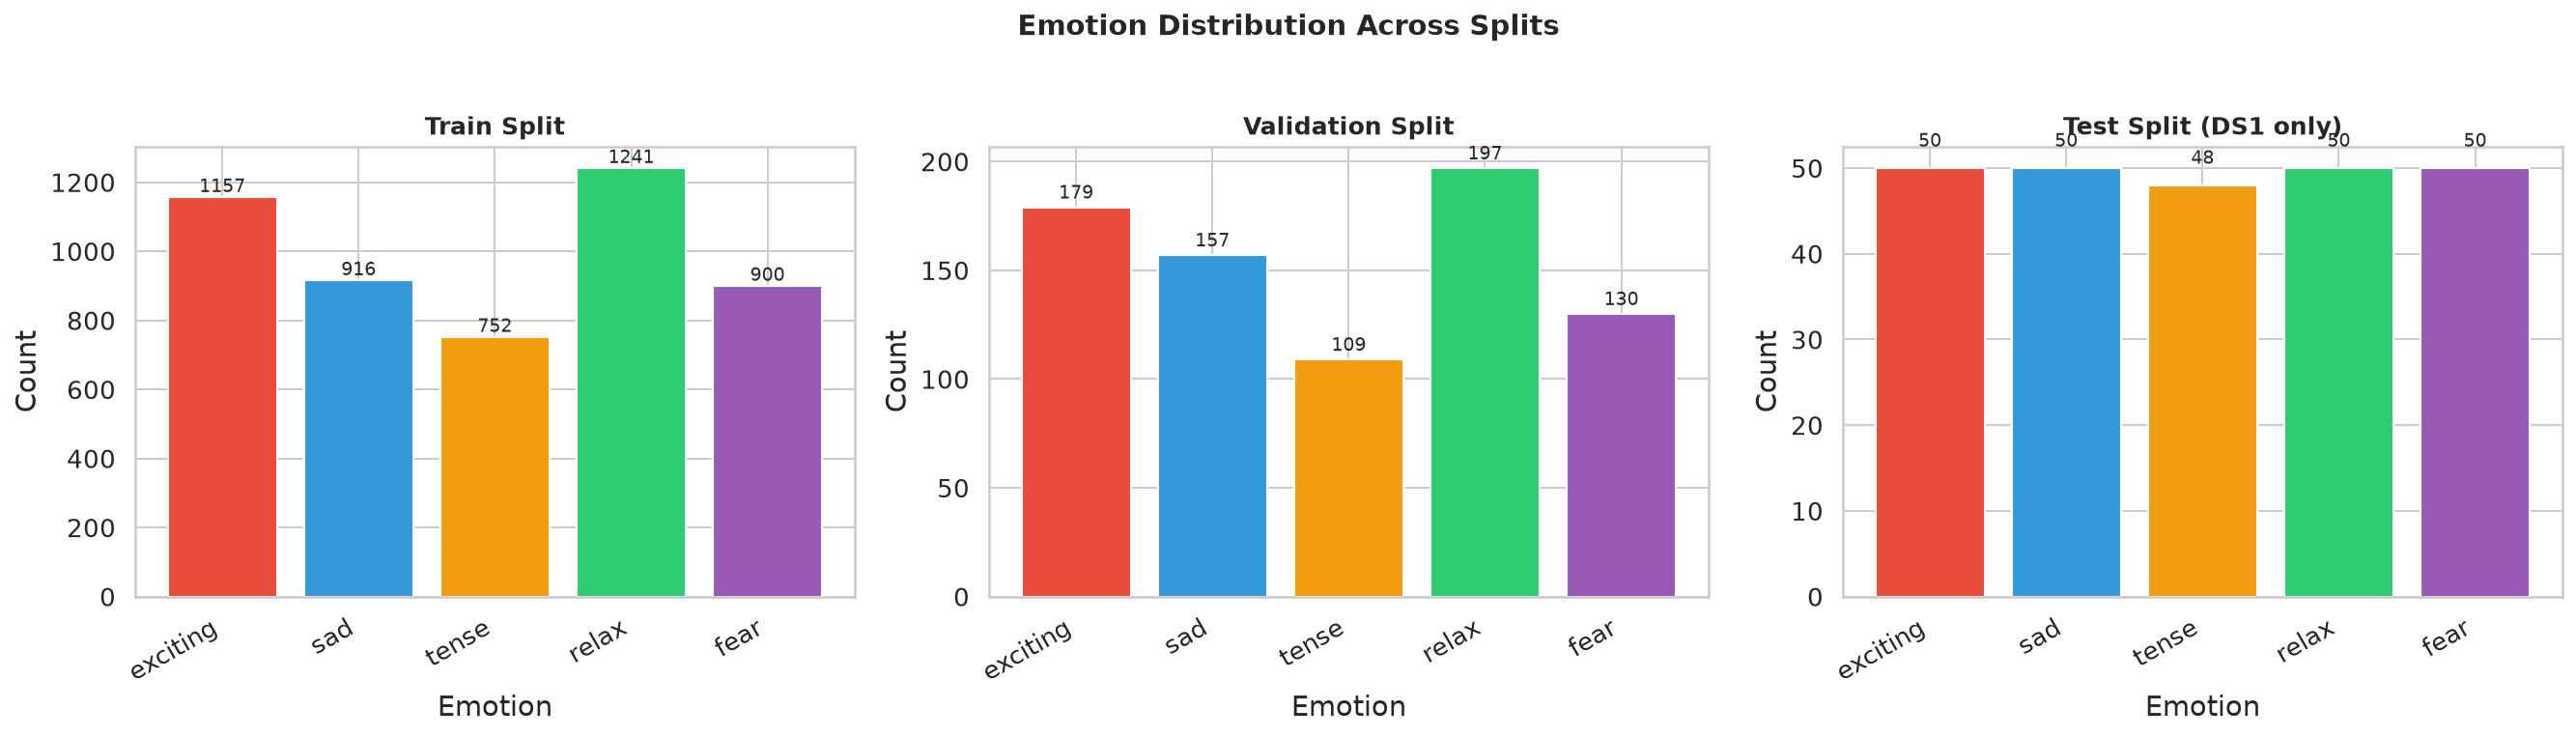

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
split_titles = {"train": "Train Split", "val": "Validation Split", "test": "Test Split (DS1 only)"}

for ax, split in zip(axes, ["train", "val", "test"]):
    sub = ann_df[ann_df["split"] == split]["vid_emotion"].value_counts().reindex(KNOWN_EMOTIONS).fillna(0)
    if sub.sum() == 0:
        ax.set_visible(False)
        continue
    colors = [EMOTION_PALETTE[e] for e in sub.index]
    bars = ax.bar(sub.index, sub.values, color=colors, edgecolor="white")
    ax.set_title(split_titles.get(split, split), fontsize=12, fontweight="bold")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.set_xticklabels(sub.index, rotation=30, ha="right")
    for bar, val in zip(bars, sub.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                    str(int(val)), ha="center", va="bottom", fontsize=9)

plt.suptitle("Emotion Distribution Across Splits", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("04_per_split_emotion_distribution", fig)
plt.show()


**Interpretation.**
Inspecting label distributions across splits validates whether the dataset was split
in a **stratified** manner (i.e., each split preserves the same class proportions as the full dataset).
Significant deviations between train and validation emotion ratios would indicate non-stratified
splitting — a data leakage risk that inflates validation accuracy on dominant classes.

A chi-square goodness-of-fit test below formally tests split homogeneity.


### 4.3 — Stratification Test (Chi-Square)

In [12]:
from scipy.stats import chi2_contingency

# Build contingency table: rows = splits, columns = emotion classes
ct = ann_df.groupby(["split", "vid_emotion"]).size().unstack(fill_value=0)
ct = ct.reindex(columns=list(KNOWN_EMOTIONS), fill_value=0)

chi2, p, dof, expected = chi2_contingency(ct)

print("=== Chi-Square Test: Label Distribution Homogeneity Across Splits ===")
print(f"  Chi² statistic : {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value        : {p:.6f}")
print()
if p < 0.05:
    print("  ⚠  RESULT: Reject H₀ — label distribution is NOT homogeneous across splits.")
    print("     The train/val/test splits have statistically different class proportions.")
    print("     This may be intentional (DS-specific splits) but warrants monitoring.")
else:
    print("  ✓  RESULT: Fail to reject H₀ — label distributions are homogeneous across splits.")

print("\nContingency Table (rows = splits):")
print(ct.to_string())


=== Chi-Square Test: Label Distribution Homogeneity Across Splits ===
  Chi² statistic : 9.5972
  Degrees of freedom: 8
  p-value        : 0.294442

  ✓  RESULT: Fail to reject H₀ — label distributions are homogeneous across splits.

Contingency Table (rows = splits):
vid_emotion  exciting  sad  tense  relax  fear
split                                         
test               50   50     48     50    50
train            1157  916    752   1241   900
val               179  157    109    197   130


### 4.4 — Class Imbalance Quantification

=== Training Set Class Imbalance Analysis ===
  Total training samples : 4,966
  Number of classes      : 5
  Imbalance ratio        : 1.65×  (max/min count)

  Emotion        Count   Fraction     Weight
  --------------------------------------------
  exciting       1,157     0.233     0.8584
  sad              916     0.184     1.0843
  tense            752     0.151     1.3207
  relax          1,241     0.250     0.8003
  fear             900     0.181     1.1036

  Severity: MODERATE (1.5–3×) — class weights in loss function recommended.
  Saved → eda_outputs/05_class_weights.png


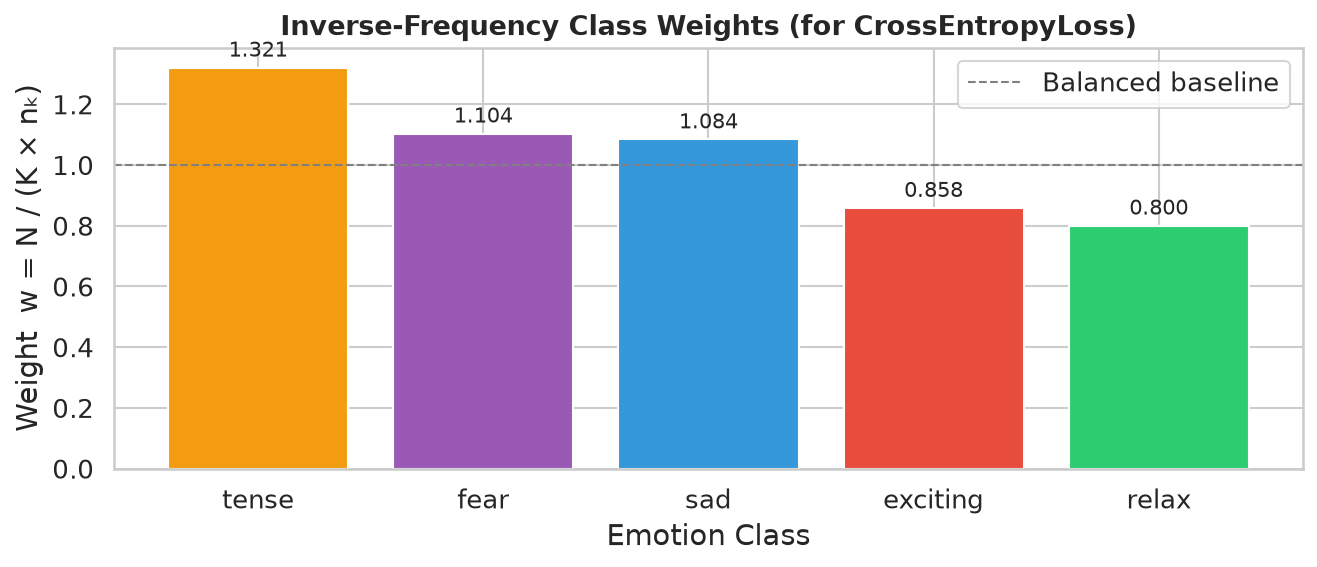


Class weights exported → eda_outputs/class_weights.json


In [13]:
train_df   = ann_df[ann_df["split"] == "train"]
emo_train  = train_df["vid_emotion"].value_counts().reindex(KNOWN_EMOTIONS).fillna(0).astype(int)
n_classes  = len(KNOWN_EMOTIONS)
n_samples  = emo_train.sum()

class_weights = n_samples / (n_classes * emo_train)
imbalance_ratio = emo_train.max() / emo_train.min()

print("=== Training Set Class Imbalance Analysis ===")
print(f"  Total training samples : {n_samples:,}")
print(f"  Number of classes      : {n_classes}")
print(f"  Imbalance ratio        : {imbalance_ratio:.2f}×  (max/min count)")
print()
print(f"  {'Emotion':<12} {'Count':>7} {'Fraction':>10} {'Weight':>10}")
print("  " + "-" * 44)
for emo in KNOWN_EMOTIONS:
    cnt  = int(emo_train[emo])
    frac = cnt / n_samples
    w    = class_weights[emo]
    print(f"  {emo:<12} {cnt:>7,} {frac:>9.3f}  {w:>9.4f}")

print()
if imbalance_ratio > 3.0:
    print("  Severity: SEVERE (>3×) — apply both class weighting AND weighted sampling.")
elif imbalance_ratio > 1.5:
    print("  Severity: MODERATE (1.5–3×) — class weights in loss function recommended.")
else:
    print("  Severity: MILD (<1.5×) — uniform sampling is likely sufficient.")

# ── Visualise weights ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
cw_sorted = class_weights.sort_values(ascending=False)
colors    = [EMOTION_PALETTE[e] for e in cw_sorted.index]
bars = ax.bar(cw_sorted.index, cw_sorted.values, color=colors, edgecolor="white")
ax.set_title("Inverse-Frequency Class Weights (for CrossEntropyLoss)", fontsize=13, fontweight="bold")
ax.set_xlabel("Emotion Class")
ax.set_ylabel("Weight  w = N / (K × nₖ)")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Balanced baseline")
ax.legend()
for bar, val in zip(bars, cw_sorted.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
save_fig("05_class_weights", fig)
plt.show()

# Export weights
weights_dict = {str(k): float(v) for k, v in class_weights.items()}
with open(OUT_DIR / "class_weights.json", "w") as f:
    json.dump(weights_dict, f, indent=2)
print(f"\nClass weights exported → {OUT_DIR}/class_weights.json")


**Interpretation.**
Inverse-frequency weights `w_k = N / (K × n_k)` rescale the loss contribution of each class
proportional to its rarity. A weight > 1.0 means the class is under-represented and will
receive proportionally higher gradient signal during backpropagation.

These weights should be passed directly to `nn.CrossEntropyLoss(weight=torch.tensor([w_0, ..., w_K]))`.
The order must match the class index mapping (`vid_enc` column in the annotations, 0 = exciting, 1 = sad, 2 = relax, 3 = fear, 4 = tense — verify per dataset).


---
## 5 · Match / Mismatch Pair Analysis

The EmoMV dataset is originally designed for **music-video emotion matching** — predicting
whether the video's emotion aligns with the background music's emotion (binary label: 1/0).
For our fine-tuning task we use only the video emotion label, but understanding the
match/mismatch structure is important for:
1. Selecting which subset of pairs to include in training (matched-only vs. all pairs).
2. Understanding whether mismatched pairs introduce label noise in the video stream.


  Saved → eda_outputs/06_match_mismatch_distribution.png


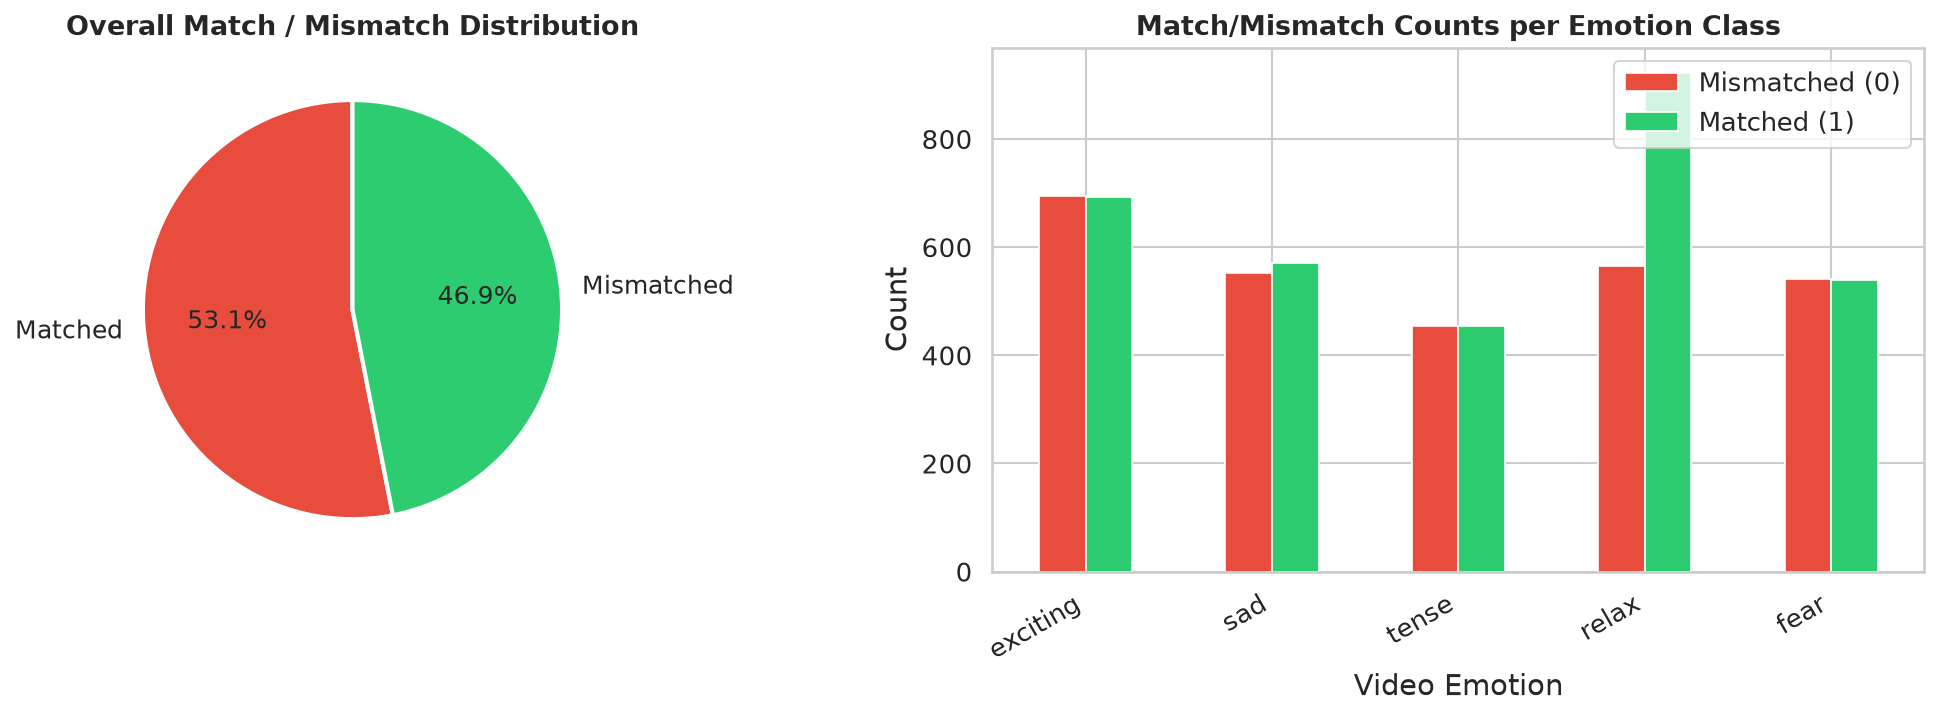


Match label breakdown:
  label=0: 2,808 (46.9%)
  label=1: 3,178 (53.1%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Global M/M distribution ──────────────────────────────────────
mm_global = ann_df["match_lbl"].value_counts().rename({0: "Mismatched", 1: "Matched"})
axes[0].pie(mm_global, labels=mm_global.index, autopct="%1.1f%%",
            colors=["#E74C3C", "#2ECC71"],
            wedgeprops={"edgecolor": "white", "linewidth": 2},
            textprops={"fontsize": 12}, startangle=90)
axes[0].set_title("Overall Match / Mismatch Distribution", fontsize=13, fontweight="bold")

# ── M/M by emotion class ─────────────────────────────────────────
mm_emo = ann_df.groupby(["vid_emotion", "match_lbl"]).size().unstack(fill_value=0)
mm_emo.columns = ["Mismatched (0)", "Matched (1)"]
mm_emo = mm_emo.reindex(list(KNOWN_EMOTIONS), fill_value=0)
mm_emo.plot(kind="bar", ax=axes[1], color=["#E74C3C", "#2ECC71"],
            edgecolor="white", linewidth=0.8)
axes[1].set_title("Match/Mismatch Counts per Emotion Class", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Video Emotion")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].legend(loc="upper right")

plt.tight_layout()
save_fig("06_match_mismatch_distribution", fig)
plt.show()

print(f"\nMatch label breakdown:")
for lbl, grp in ann_df.groupby("match_lbl"):
    print(f"  label={lbl}: {len(grp):,} ({100*len(grp)/len(ann_df):.1f}%)")


### 5.1 — Video × Music Emotion Cross-Tabulation

  Saved → eda_outputs/07_video_music_emotion_crosstab.png


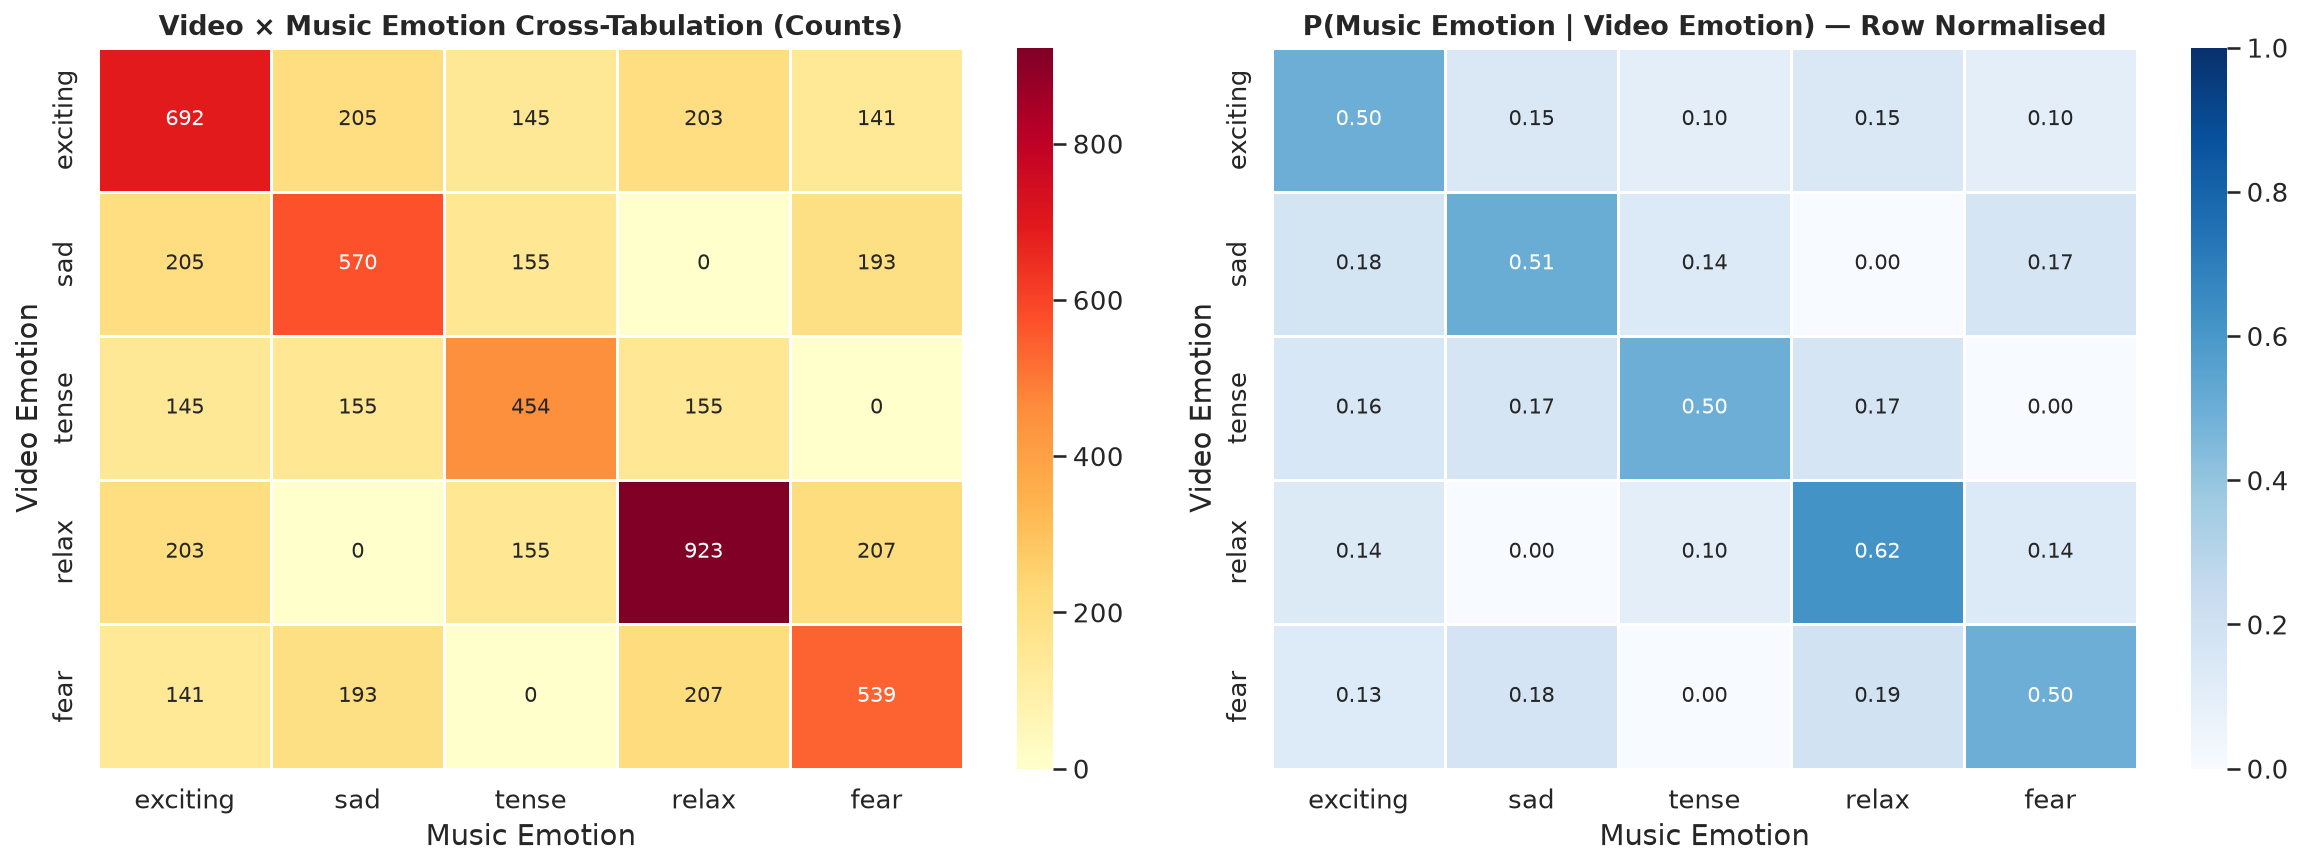

Pairs where vid_emo == mus_emo (on-diagonal): 3,178 (53.1%)
Pairs where vid_emo != mus_emo (off-diagonal): 2,808 (46.9%)


In [15]:
# Pivot: rows = video emotion, cols = music emotion
cross = pd.crosstab(
    ann_df["vid_emotion"].reindex(ann_df.index),
    ann_df["mus_emotion"],
).reindex(index=list(KNOWN_EMOTIONS), columns=list(KNOWN_EMOTIONS), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute count heatmap
sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5,
            ax=axes[0], annot_kws={"size": 10})
axes[0].set_title("Video × Music Emotion Cross-Tabulation (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Music Emotion")
axes[0].set_ylabel("Video Emotion")

# Row-normalised heatmap (conditional probability P(mus_emo | vid_emo))
cross_norm = cross.div(cross.sum(axis=1), axis=0)
sns.heatmap(cross_norm, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5,
            ax=axes[1], annot_kws={"size": 10}, vmin=0, vmax=1)
axes[1].set_title("P(Music Emotion | Video Emotion) — Row Normalised", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Music Emotion")
axes[1].set_ylabel("Video Emotion")

plt.tight_layout()
save_fig("07_video_music_emotion_crosstab", fig)
plt.show()

# Diagonal = matched pairs
diagonal_sum = np.trace(cross.values)
total = cross.values.sum()
print(f"Pairs where vid_emo == mus_emo (on-diagonal): {diagonal_sum:,} ({100*diagonal_sum/total:.1f}%)")
print(f"Pairs where vid_emo != mus_emo (off-diagonal): {total - diagonal_sum:,} ({100*(total-diagonal_sum)/total:.1f}%)")


**Interpretation.**
The diagonal of the cross-tabulation counts **congruent pairs** (matched video-music emotion).
The off-diagonal entries are **mismatched pairs** constructed by the dataset authors to provide
contrastive negative examples for the matching task.

The row-normalised matrix shows the conditional distribution `P(music emotion | video emotion)`.
A perfectly balanced mismatch construction would show equal probability mass across all off-diagonal
entries. Deviations indicate that certain emotion pairs (e.g., exciting video paired with sad music)
were more frequently constructed as negatives — a potential source of pairing bias.

**For VideoMAE/CLIP fine-tuning:** since only the video stream label matters, the music emotion
column can be safely ignored. However, including mismatched pairs doubles the effective training set
size without adding new video clips — each video appears in both a matched and a mismatched context.
We recommend training on **all pairs** (both matched and mismatched) to maximise video diversity.


---
## 6 · Physical Video Inventory (Disk Scan)

Not all annotation rows have corresponding `.mp4` files on disk. DS1 MATCH clips are
stored as pre-extracted feature vectors (`.h5`) rather than raw video. This section
audits the **actual file count** and compares it against annotation coverage.


In [16]:
print("Scanning disk for .mp4 files (may take a moment)...")
all_mp4s = sorted(BASE_DIR.rglob("*.mp4"))
print(f"Total .mp4 files found: {len(all_mp4s):,}")
print()

# Breakdown by sub-dataset
ds_file_counts = {}
for p in all_mp4s:
    # Determine which dataset this file belongs to
    parts = p.parts
    for part in parts:
        if part in ("Dataset1", "Dataset2", "Dataset3"):
            ds_file_counts[part] = ds_file_counts.get(part, 0) + 1
            break

print("Physical .mp4 count per sub-dataset:")
for ds, cnt in sorted(ds_file_counts.items()):
    print(f"  {ds}: {cnt:,} files")

# Breakdown by split folder
folder_counts = Counter(p.parent.name for p in all_mp4s)
print("\nPhysical .mp4 count per subfolder (top 15):")
for folder, cnt in folder_counts.most_common(15):
    print(f"  {folder:<40s}: {cnt:,}")


Scanning disk for .mp4 files (may take a moment)...
Total .mp4 files found: 6,452

Physical .mp4 count per sub-dataset:
  Dataset1: 5,164 files
  Dataset2: 736 files
  Dataset3: 552 files

Physical .mp4 count per subfolder (top 15):
  DS1_TRAIN_MATCH                         : 2,208
  DS1_TRAIN_MISMATCH                      : 1,902
  DS1_VAL_MATCH                           : 310
  video                                   : 250
  DS2_train_match                         : 248
  DS2_train_mismatch                      : 248
  DS1_VAL_MISMATCH                        : 246
  DS3_train_match                         : 180
  DS3_train_mismatch                      : 180
  DS1_TEST_MATCH                          : 124
  DS1_TEST_MISMATCH                       : 124
  DS2_val_for_retrieval                   : 120
  DS3_val_for_retrieval                   : 96
  DS2_val_match                           : 60
  DS2_val_mismatch                        : 60


=== Annotation ↔ Disk Coverage ===
  Total annotation rows          : 5,986
  Unique paths in annotations    : 5,986
  Physical .mp4 files on disk    : 6,452
  Annotated AND on disk          : 5,986
  Annotated but MISSING on disk  : 0  ← DS1 MATCH (features-only)
  On disk but NOT in any annotation: 466
  Saved → eda_outputs/08_coverage_disk_vs_annotations.png


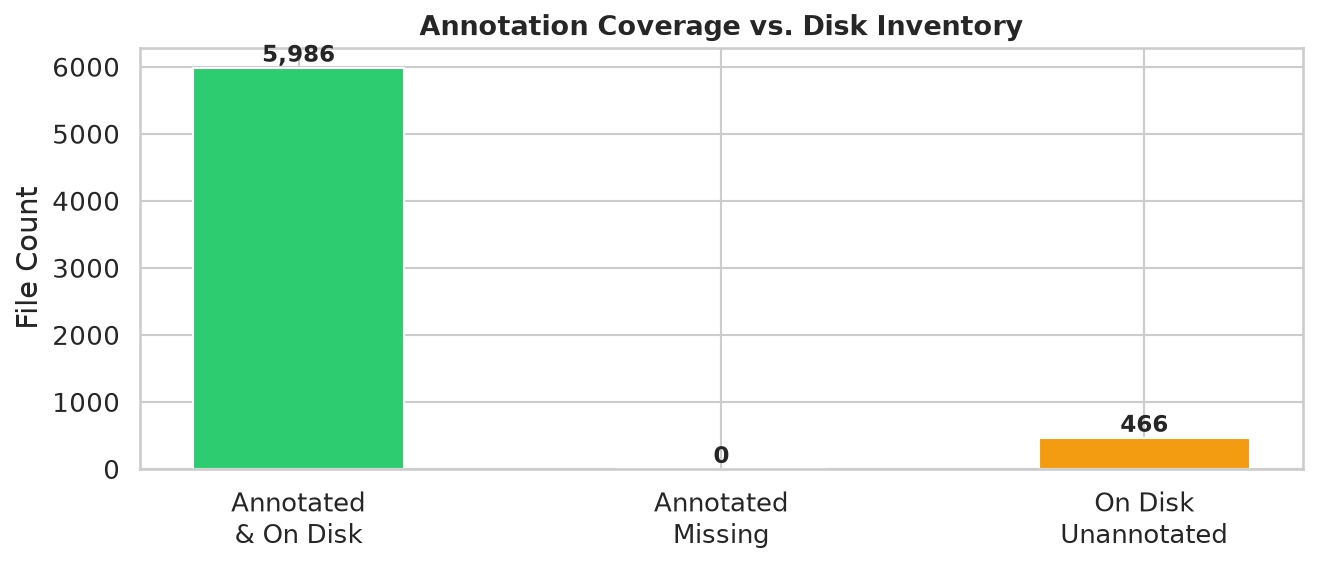

In [17]:
# Coverage analysis: annotations vs disk
ann_paths = set(ann_df["abs_path"].tolist())
disk_paths = {str(p) for p in all_mp4s}

in_ann_on_disk       = ann_paths & disk_paths
in_ann_not_on_disk   = ann_paths - disk_paths
on_disk_not_in_ann   = disk_paths - ann_paths

print("=== Annotation ↔ Disk Coverage ===")
print(f"  Total annotation rows          : {len(ann_df):,}")
print(f"  Unique paths in annotations    : {len(ann_paths):,}")
print(f"  Physical .mp4 files on disk    : {len(disk_paths):,}")
print(f"  Annotated AND on disk          : {len(in_ann_on_disk):,}")
print(f"  Annotated but MISSING on disk  : {len(in_ann_not_on_disk):,}  ← DS1 MATCH (features-only)")
print(f"  On disk but NOT in any annotation: {len(on_disk_not_in_ann):,}")

# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
categories  = ["Annotated\n& On Disk", "Annotated\nMissing", "On Disk\nUnannotated"]
values      = [len(in_ann_on_disk), len(in_ann_not_on_disk), len(on_disk_not_in_ann)]
bar_colors  = ["#2ECC71", "#E74C3C", "#F39C12"]
bars = ax.bar(categories, values, color=bar_colors, edgecolor="white", width=0.5)
ax.set_title("Annotation Coverage vs. Disk Inventory", fontsize=13, fontweight="bold")
ax.set_ylabel("File Count")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
save_fig("08_coverage_disk_vs_annotations", fig)
plt.show()


**Interpretation.**
The coverage gap (annotated but missing on disk) corresponds entirely to the DS1 MATCH
subfolder design: the dataset authors chose to ship pre-extracted SlowFast and VGGish
feature vectors (`.h5`) for DS1 MATCH clips to reduce storage footprint.

For fine-tuning VideoMAE/CLIP (which requires **raw frame pixels**), only clips where
`.mp4` files are present on disk are usable. The DS1 MATCH clips therefore require
either (a) downloading the original MV source material, or (b) using the pre-extracted
features as a fixed visual backbone — bypassing VideoMAE/CLIP feature extraction.

**Recommendation:** Build the fine-tuning dataset from:
- All DS2 and DS3 videos (raw MP4, available)
- DS1 MISMATCH videos (raw MP4, available)
- Skip DS1 MATCH unless raw videos are separately acquired


---
## 7 · Video Metadata Extraction (via ffprobe)

Video metadata (duration, resolution, frame rate, codec) determines the preprocessing
pipeline: frame sampling strategy, spatial resizing, and normalization parameters.
We use `ffprobe` for lossless metadata extraction — no frame decoding required.

> **Note:** Probing all ~6 000+ files takes several minutes. Set `SAMPLE_FRACTION = 1.0`
> to probe everything, or a smaller value (e.g., `0.2`) for a quick exploratory pass.


In [18]:
SAMPLE_FRACTION = 1.0   # 1.0 = all files; 0.2 = random 20% sample

# Build file-to-label mapping from annotation (prefer annotated labels)
path_to_label = {}
for _, row in ann_df[ann_df["exists"]].iterrows():
    path_to_label[row["abs_path"]] = {
        "vid_emotion": row["vid_emotion"],
        "dataset":     row["dataset"],
        "split":       row["split"],
        "match_lbl":   row["match_lbl"],
    }

# Files with no annotation label — infer emotion from DS1 MISMATCH filename prefix
def infer_from_stem(stem: str) -> str:
    m = re.match(r"^([a-zA-Z]+)_", stem)
    return normalise_emotion(m.group(1)) if m else "unknown"

# Select which files to probe
probe_files = all_mp4s
if SAMPLE_FRACTION < 1.0:
    np.random.seed(42)
    n = max(100, int(len(all_mp4s) * SAMPLE_FRACTION))
    probe_files = sorted(np.random.choice(all_mp4s, size=n, replace=False))

print(f"Probing {len(probe_files):,} / {len(all_mp4s):,} files via ffprobe ...")
meta_rows = []

for p in tqdm(probe_files, desc="ffprobe", unit="file"):
    abs_str = str(p)
    lbl_info = path_to_label.get(abs_str, {})
    vid_emo  = lbl_info.get("vid_emotion") or infer_from_stem(p.stem)
    dataset  = lbl_info.get("dataset", "DS1")  # fallback for DS1 MISMATCH
    split    = lbl_info.get("split", "unknown")
    match_l  = lbl_info.get("match_lbl", -1)

    meta = ffprobe_meta(abs_str)
    if meta is None:
        meta = {"corrupt": True}

    meta_rows.append({
        "abs_path":   abs_str,
        "filename":   p.name,
        "vid_emotion": vid_emo,
        "dataset":    dataset,
        "split":      split,
        "match_lbl":  match_l,
        **meta,
    })

meta_df = pd.DataFrame(meta_rows)
valid   = meta_df[~meta_df["corrupt"].fillna(False)].copy()

# Derived columns
valid["aspect_ratio"] = valid.apply(
    lambda r: aspect_ratio_str(r.get("width", 0) or 0, r.get("height", 0) or 0), axis=1)
valid["orientation"]  = valid.apply(
    lambda r: orientation(r.get("width", 0) or 0, r.get("height", 0) or 0), axis=1)
valid["resolution"]   = valid.apply(
    lambda r: f"{int(r.get('width',0) or 0)}×{int(r.get('height',0) or 0)}", axis=1)
valid["pixel_count"]  = (valid["width"].fillna(0) * valid["height"].fillna(0)).astype(int)

print(f"\nProbed: {len(meta_df):,} total | {len(valid):,} valid | {meta_df['corrupt'].sum():,} corrupt")
valid.describe(include="all").T


Probing 6,452 / 6,452 files via ffprobe ...


ffprobe:   0%|          | 0/6452 [00:00<?, ?file/s]


Probed: 6,452 total | 6,452 valid | 0 corrupt


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
abs_path,6452,6452,/Users/rafiabhista/Documents/code/apple/c1_aud...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
filename,6452,6344,-1Wp8TqoK9U.mp4,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vid_emotion,6452,24,relax,1488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,6452,3,DS1,5380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,6452,4,train,4966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_lbl,6452.0,NaN,NaN,NaN,0.420335,0.623029,-1.0,0.0,0.0,1.0,1.0
duration_s,6452.0,NaN,NaN,NaN,27.602641,9.850785,9.009,28.931995,29.996633,30.01797,392.370794
file_size_mb,6452.0,NaN,NaN,NaN,2.522557,1.765743,0.2597,1.522025,2.19745,2.63135,19.9357
bit_rate_kbps,6452.0,NaN,NaN,NaN,781.674892,488.946326,147.8,496.9,669.65,788.05,5429.2
corrupt,6452,1,False,6452,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
print("halo")

halo


---
## 8 · Temporal Analysis

Video duration and frame count directly determine the frame sampling strategy for
VideoMAE (which expects a fixed number of frames T=16) and CLIP (which processes
individual frames or fixed-length clips).


=== Duration Statistics (seconds) ===
  count   : 6452.000
  mean    : 27.603
  std     : 9.851
  min     : 9.009
  5%      : 10.008
  25%     : 28.932
  50%     : 29.997
  75%     : 30.018
  95%     : 30.507
  max     : 392.371

  Range    : 9.01s – 392.37s
  IQR      : 28.93s – 30.02s
  Skewness : 18.522
  Kurtosis : 669.991
  Saved → eda_outputs/09_temporal_analysis.png


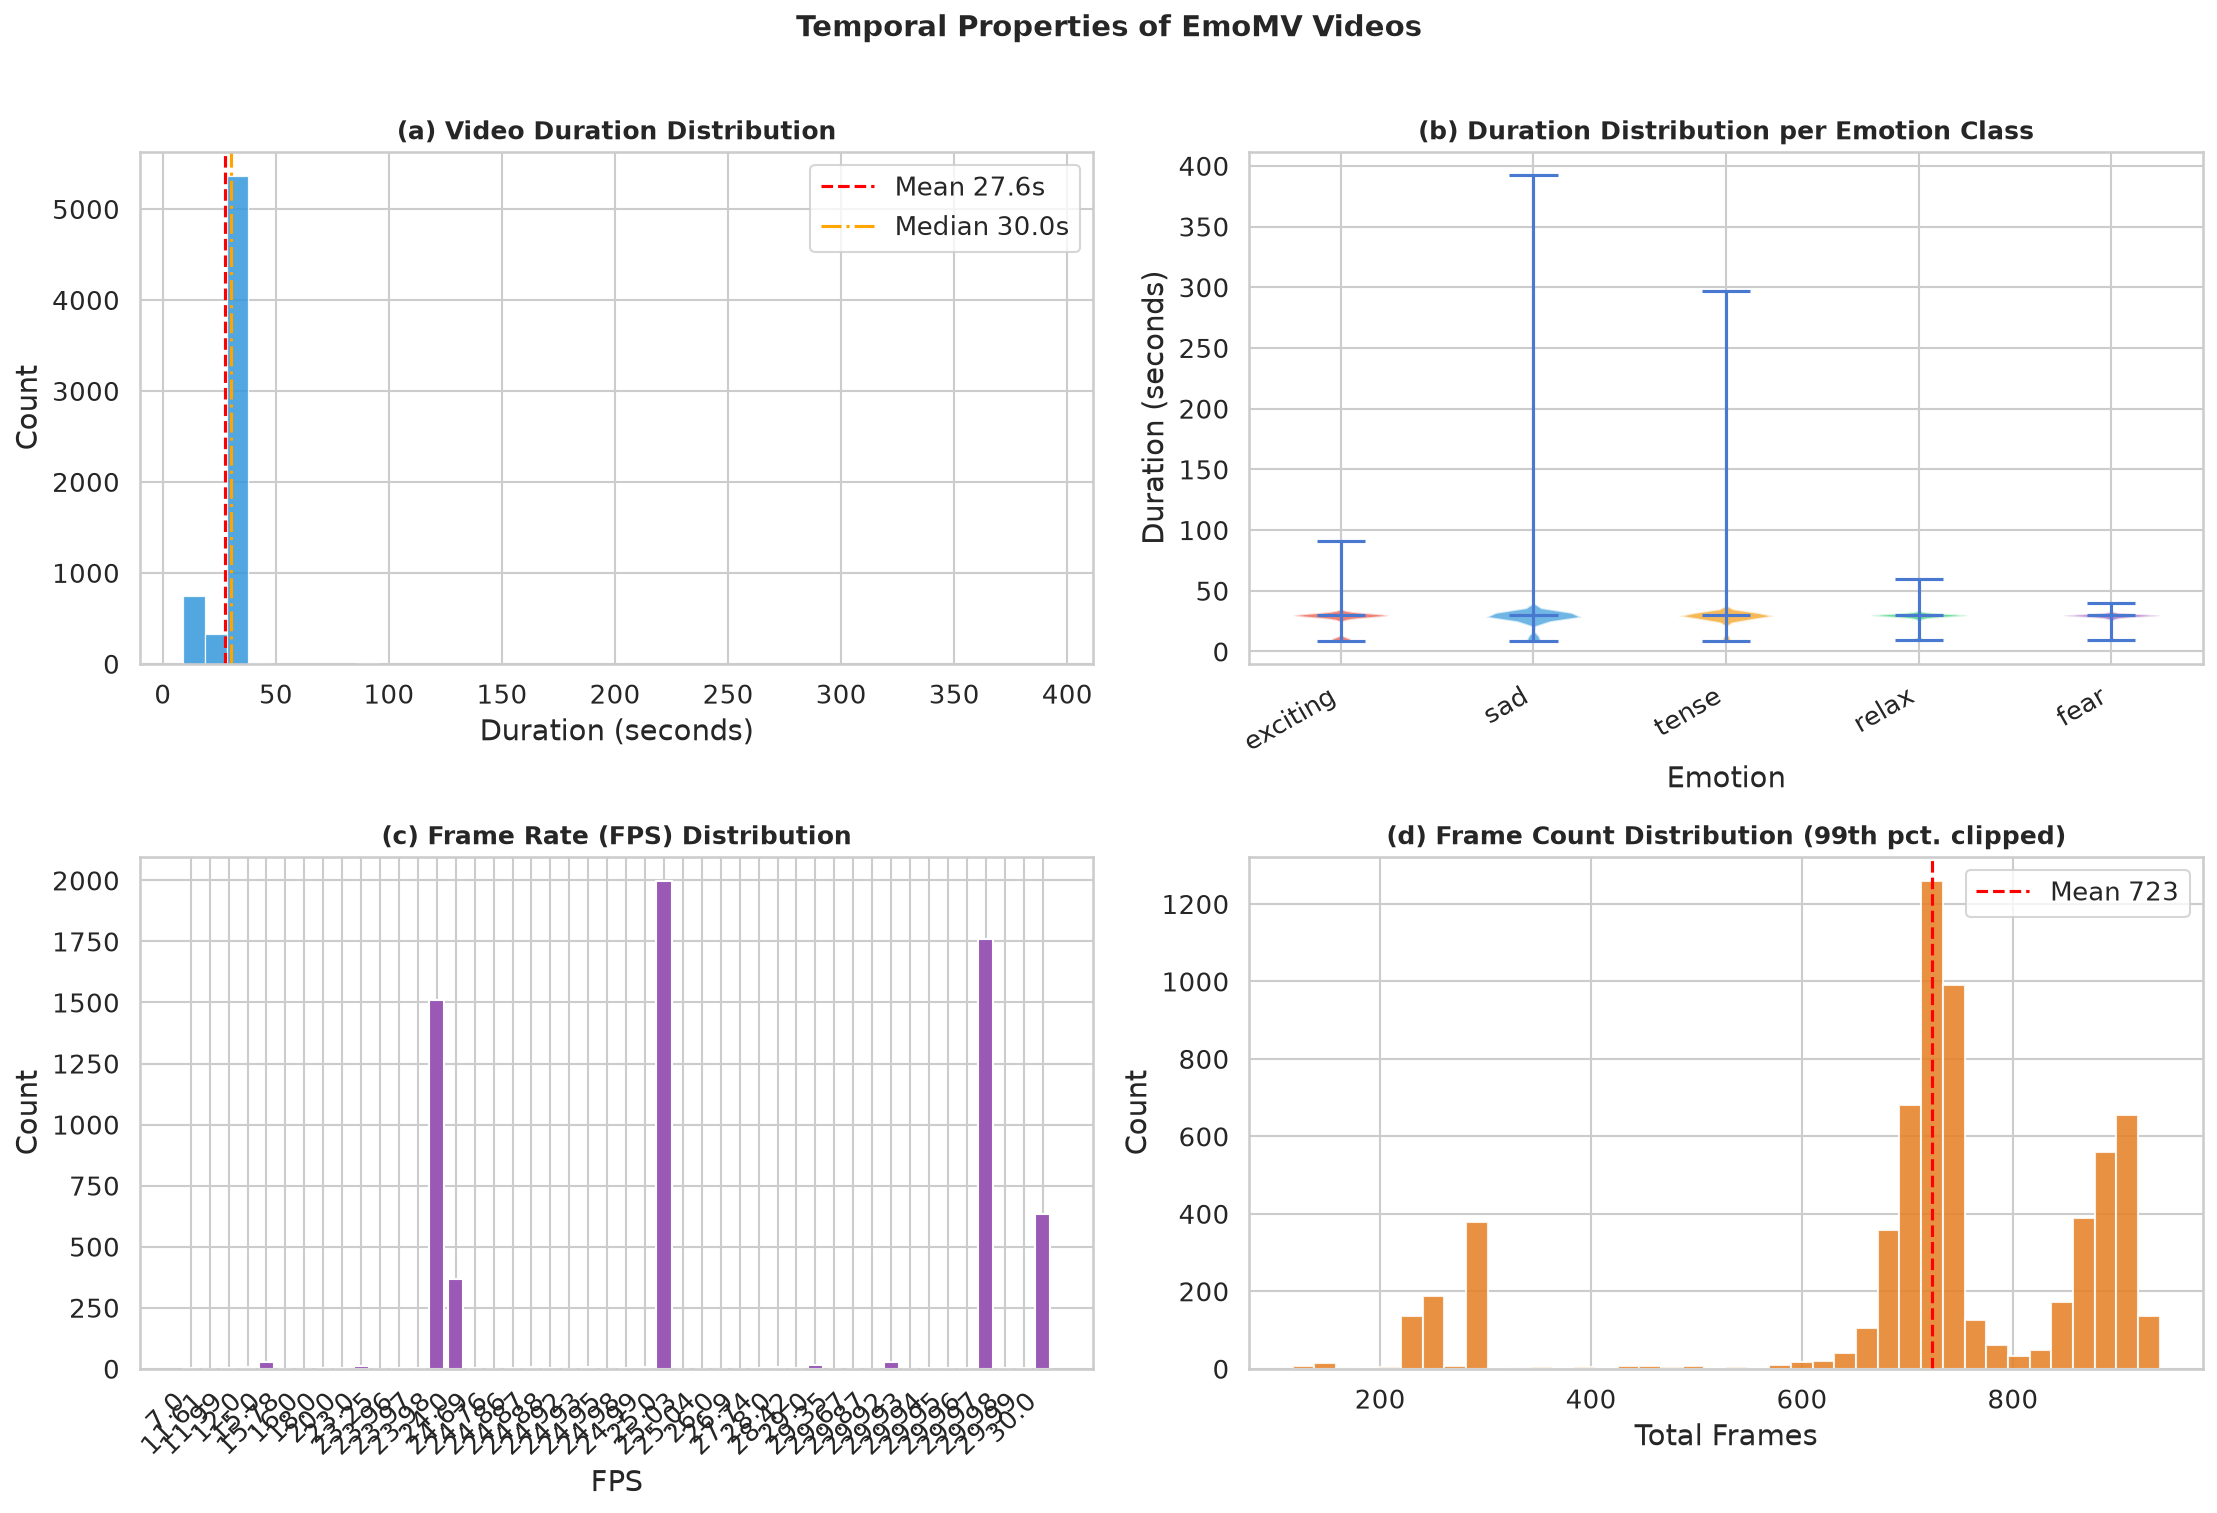

In [20]:
dur = valid["duration_s"].dropna()
fps_col = valid["fps"].dropna()
fc  = valid["frame_count"].dropna()

print("=== Duration Statistics (seconds) ===")
desc = dur.describe(percentiles=[.05, .25, .5, .75, .95])
for k, v in desc.items():
    print(f"  {k:<8}: {v:.3f}")

print(f"\n  Range    : {dur.min():.2f}s – {dur.max():.2f}s")
print(f"  IQR      : {dur.quantile(0.25):.2f}s – {dur.quantile(0.75):.2f}s")
print(f"  Skewness : {dur.skew():.3f}")
print(f"  Kurtosis : {dur.kurtosis():.3f}")

# ── Multi-panel temporal figure ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (a) Duration histogram
ax = axes[0, 0]
ax.hist(dur, bins=40, color="#3498DB", edgecolor="white", linewidth=0.6, alpha=0.85)
ax.axvline(dur.mean(), color="red",  linestyle="--", linewidth=1.5, label=f"Mean {dur.mean():.1f}s")
ax.axvline(dur.median(), color="orange", linestyle="-.", linewidth=1.5, label=f"Median {dur.median():.1f}s")
ax.set_title("(a) Video Duration Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Count")
ax.legend()

# (b) Duration by emotion (violin)
ax = axes[0, 1]
emo_order = list(KNOWN_EMOTIONS)
emotion_dur_data = [valid[valid["vid_emotion"] == e]["duration_s"].dropna().values for e in emo_order]
parts = ax.violinplot(emotion_dur_data, positions=range(len(emo_order)), showmedians=True,
                       showextrema=True)
for i, (pc, emo) in enumerate(zip(parts["bodies"], emo_order)):
    pc.set_facecolor(EMOTION_PALETTE[emo])
    pc.set_alpha(0.7)
ax.set_xticks(range(len(emo_order)))
ax.set_xticklabels(emo_order, rotation=30, ha="right")
ax.set_title("(b) Duration Distribution per Emotion Class", fontsize=12, fontweight="bold")
ax.set_xlabel("Emotion")
ax.set_ylabel("Duration (seconds)")

# (c) FPS distribution
ax = axes[1, 0]
fps_rounded = fps_col.round(2)
fps_counts  = fps_rounded.value_counts().sort_index()
ax.bar(fps_counts.index.astype(str), fps_counts.values, color="#9B59B6", edgecolor="white")
ax.set_title("(c) Frame Rate (FPS) Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("FPS")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# (d) Frame count histogram
ax = axes[1, 1]
ax.hist(fc.clip(upper=fc.quantile(0.99)), bins=40, color="#E67E22", edgecolor="white", alpha=0.85)
ax.axvline(fc.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean {fc.mean():.0f}")
ax.set_title("(d) Frame Count Distribution (99th pct. clipped)", fontsize=12, fontweight="bold")
ax.set_xlabel("Total Frames")
ax.set_ylabel("Count")
ax.legend()

plt.suptitle("Temporal Properties of EmoMV Videos", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("09_temporal_analysis", fig)
plt.show()


  Saved → eda_outputs/10_duration_per_emotion_boxplot.png


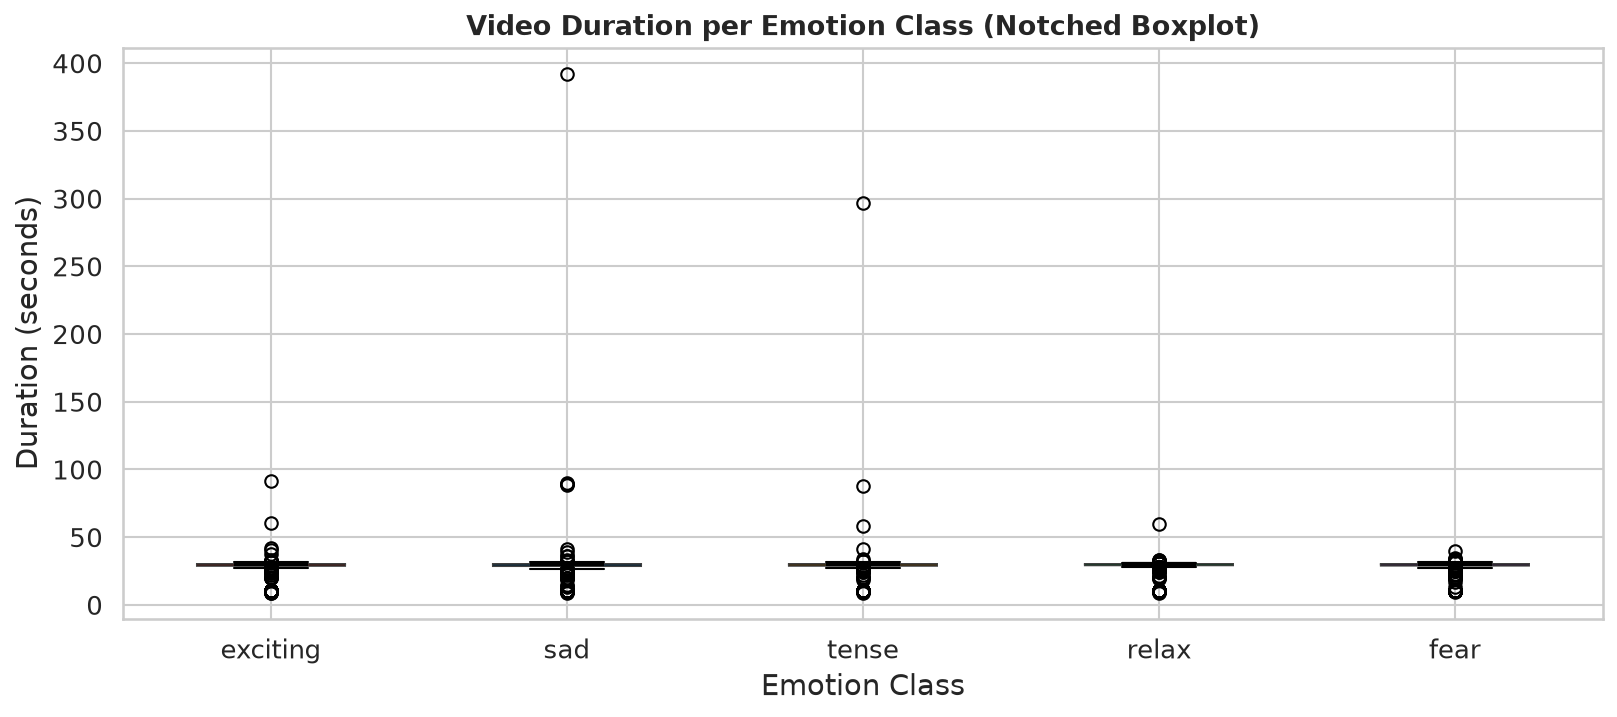


=== Median Duration per Emotion (seconds) ===
             count   min    q25  median    q75     max   mean    std
vid_emotion                                                         
exciting      1386  9.04  28.84   29.99  30.00   91.16  26.61   7.61
sad           1132  9.01  28.70   29.95  30.02  392.37  27.64  13.20
tense          909  9.01  28.90   29.91  30.01  297.08  28.34  10.67
relax         1488  9.07  29.27   30.00  30.02   60.01  28.05   5.64
fear          1097  9.64  29.03   29.96  30.03   40.08  28.52   4.52


In [22]:
# Duration per emotion — boxplot with statistics
fig, ax = plt.subplots(figsize=(11, 5))
emo_order = list(KNOWN_EMOTIONS)
dur_by_emo = [valid[valid["vid_emotion"] == e]["duration_s"].dropna().values for e in emo_order]
bp = ax.boxplot(dur_by_emo, patch_artist=True, notch=True,
                medianprops=dict(color="black", linewidth=2))
for patch, emo in zip(bp["boxes"], emo_order):
    patch.set_facecolor(EMOTION_PALETTE[emo])
    patch.set_alpha(0.75)

ax.set_title("Video Duration per Emotion Class (Notched Boxplot)", fontsize=13, fontweight="bold")
ax.set_xlabel("Emotion Class")
ax.set_ylabel("Duration (seconds)")
ax.set_xticklabels(emo_order, rotation=0)

plt.tight_layout()
save_fig("10_duration_per_emotion_boxplot", fig)
plt.show()

# Table
print("\n=== Median Duration per Emotion (seconds) ===")
dur_stats = valid.groupby("vid_emotion")["duration_s"].agg(
    count="count", min="min", q25=lambda x: x.quantile(0.25),
    median="median", q75=lambda x: x.quantile(0.75), max="max",
    mean="mean", std="std"
).reindex(list(KNOWN_EMOTIONS))
print(dur_stats.round(2).to_string())


**Interpretation.**
The duration distribution characterises how much temporal context each video provides:

- **Short clips (<10 s):** Common in DS3 (fixed 10 s segments). At 25 fps, a 10 s clip
  yields 250 frames. VideoMAE samples T=16 frames uniformly, giving one frame every ~15.6
  frames of original video — sufficient temporal coverage.

- **Medium clips (10–30 s):** The majority of DS1 MISMATCH clips fall here. Uniform
  T=16 sampling still works well; longer context may require a sliding window approach
  for temporal encoding.

- **Longer clips (>30 s):** Rare in this dataset but present. For CLIP (which processes
  single frames), a centre-frame or uniform-5-frame sampling scheme is appropriate.
  For VideoMAE, clip the video to the first 30 s or use dense sampling.

**FPS notes:** The dominant frame rate is 25 fps (PAL standard) with a minority at 29.97 fps
(NTSC). Mixed FPS across the dataset requires that all frame-sampling code operates on
**time offsets** (seconds) rather than **frame indices** to avoid inconsistency.

**Frame count skewness:** If the distribution is right-skewed (long tail of high frame counts),
the mean is pulled above the median — use the median as the reference for designing fixed-length
clip extraction.


---
## 9 · Spatial Analysis

Both VideoMAE (ViT-B/16) and CLIP (ViT-B/32) expect square 224×224 input frames.
Understanding the native resolution distribution determines the resizing / cropping
pipeline that minimises information loss.


  Saved → eda_outputs/11_spatial_analysis.png


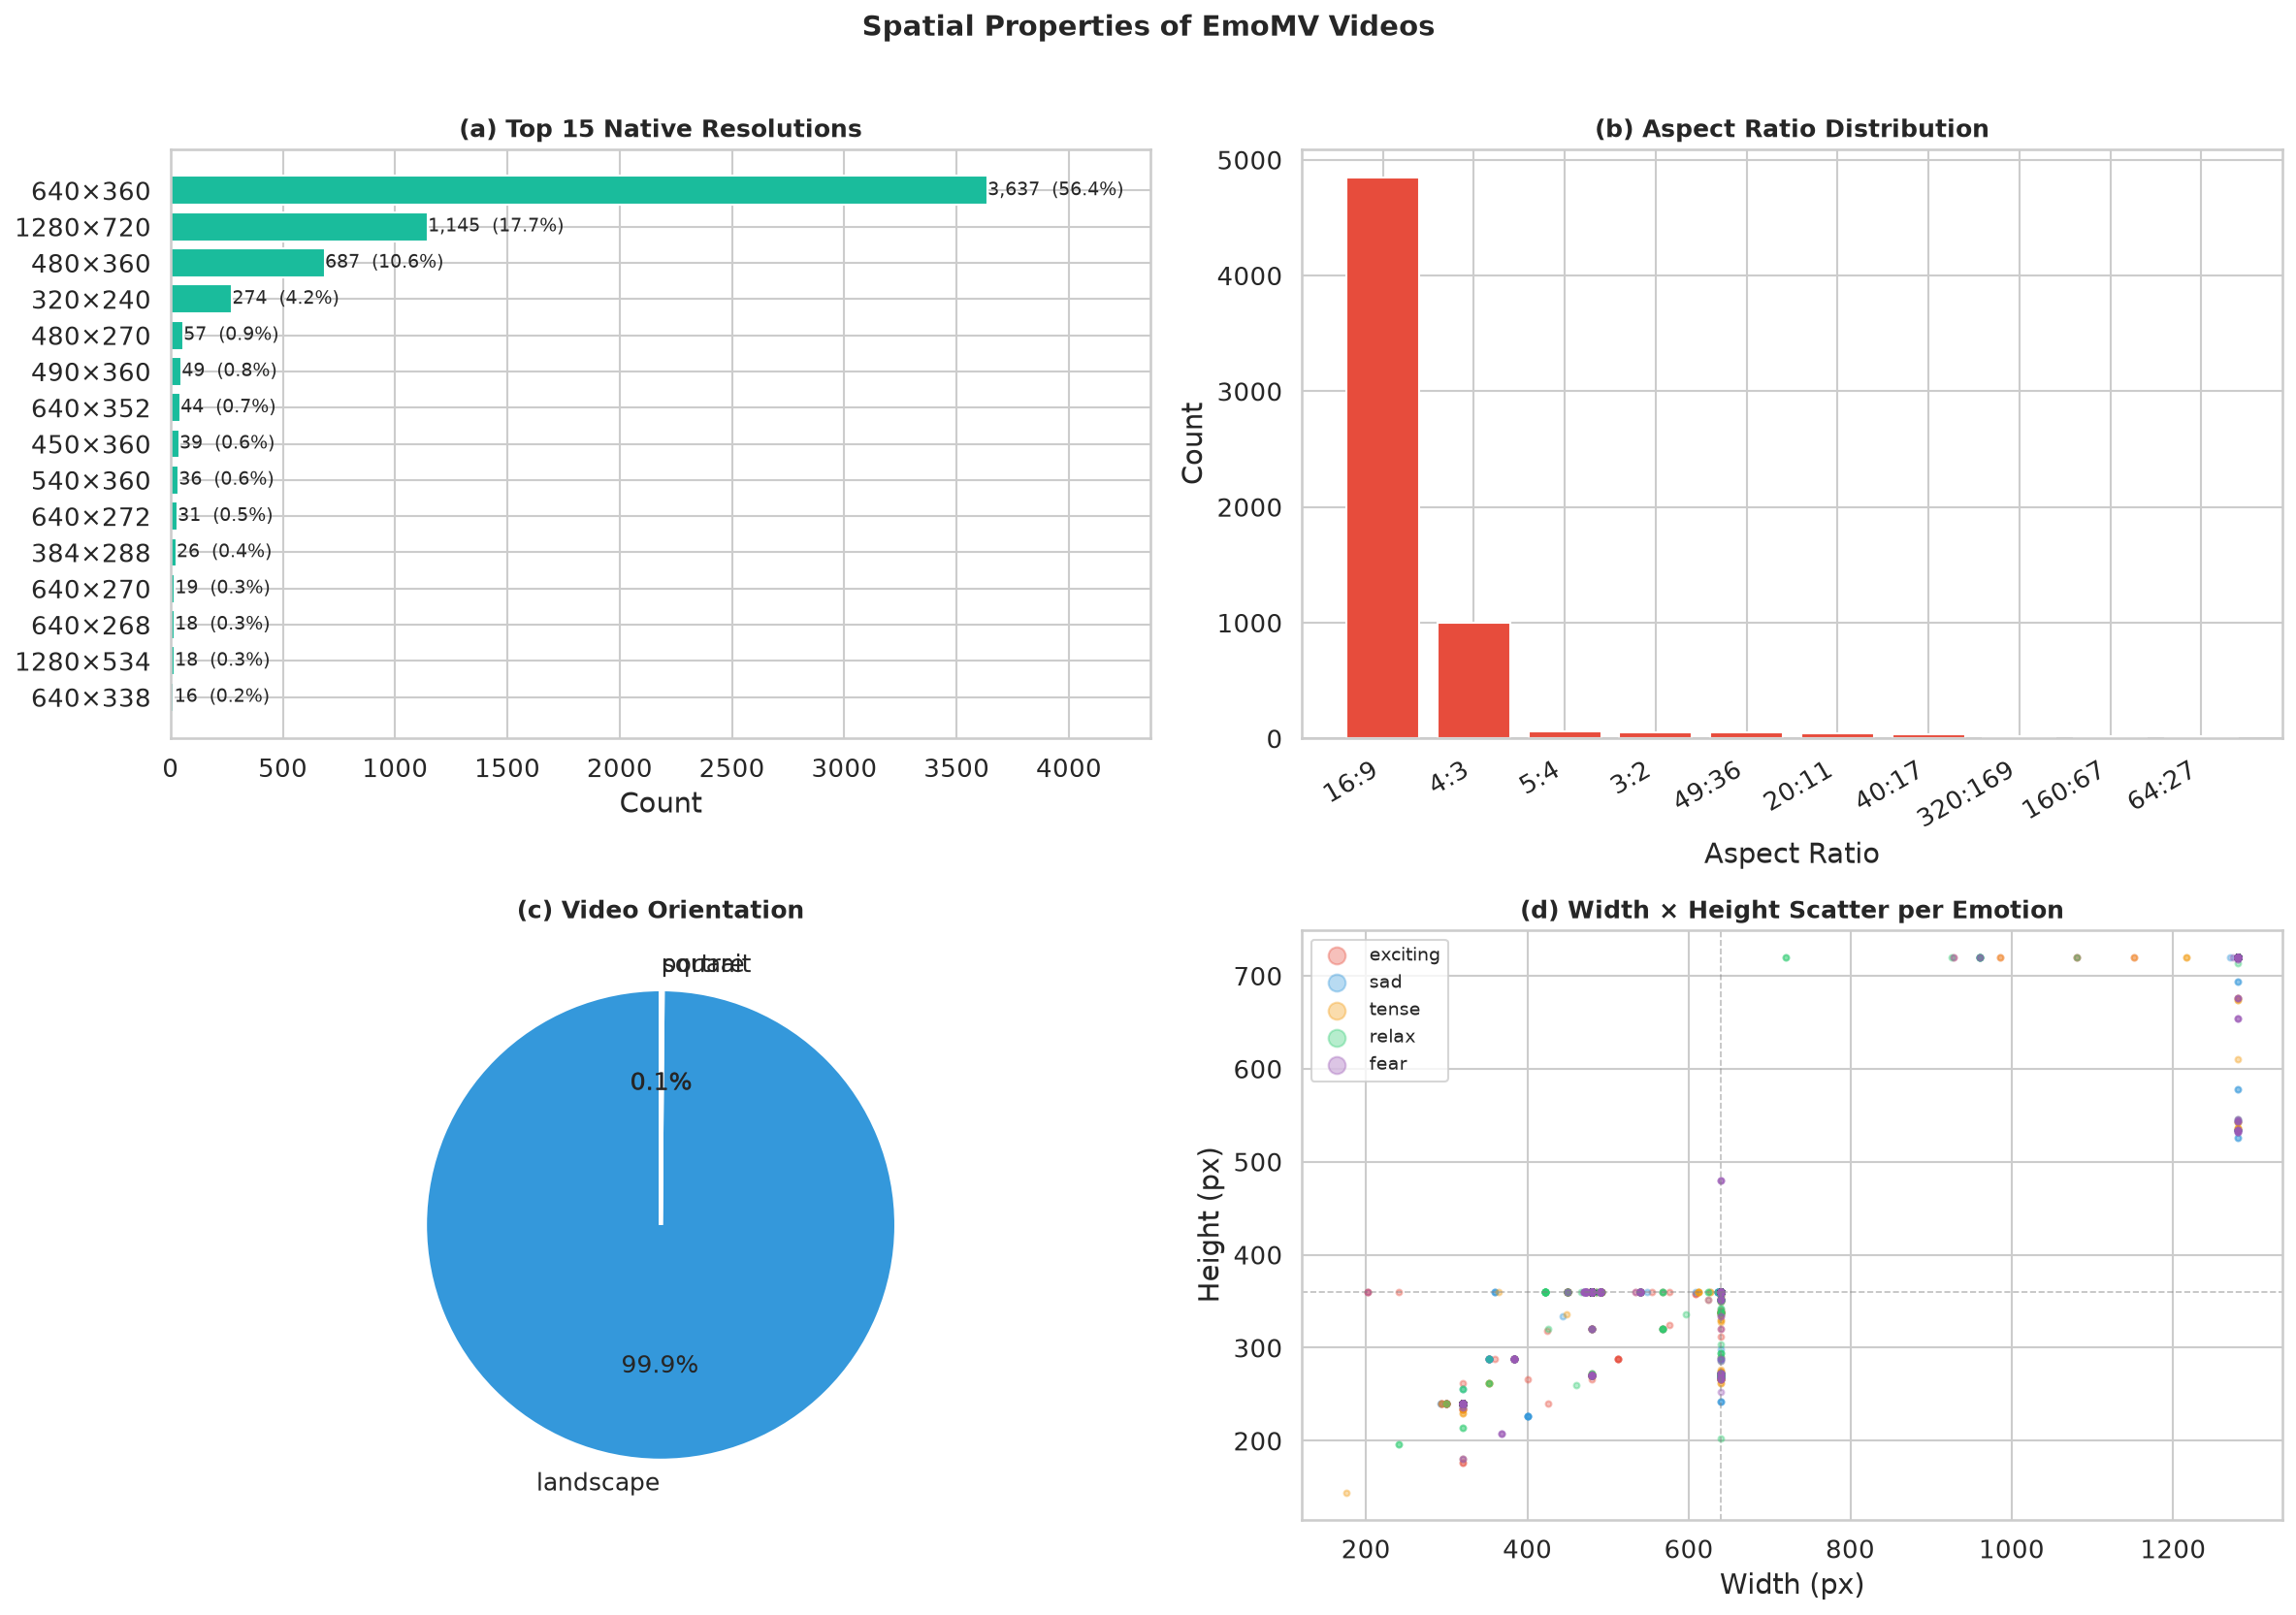


=== Spatial Summary ===
  Dominant resolution : 640×360
  Dominant AR         : 16:9
  Dominant orientation: landscape
  Width  range        : 176–1280 px
  Height range        : 144–720 px


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# (a) Resolution distribution (top 15)
ax = axes[0, 0]
res_counts = valid["resolution"].value_counts().head(15)
ax.barh(res_counts.index, res_counts.values, color="#1ABC9C", edgecolor="white")
ax.invert_yaxis()
ax.set_title("(a) Top 15 Native Resolutions", fontsize=12, fontweight="bold")
ax.set_xlabel("Count")
for i, (res, cnt) in enumerate(res_counts.items()):
    ax.text(cnt + 1, i, f"{cnt:,}  ({100*cnt/len(valid):.1f}%)", va="center", fontsize=9)
ax.set_xlim(0, res_counts.max() * 1.2)

# (b) Aspect ratio distribution
ax = axes[0, 1]
ar_counts = valid["aspect_ratio"].value_counts().head(10)
ax.bar(ar_counts.index, ar_counts.values, color="#E74C3C", edgecolor="white")
ax.set_title("(b) Aspect Ratio Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Aspect Ratio")
ax.set_ylabel("Count")
ax.set_xticklabels(ar_counts.index, rotation=30, ha="right")

# (c) Orientation
ax = axes[1, 0]
ori_counts = valid["orientation"].value_counts()
ax.pie(ori_counts, labels=ori_counts.index, autopct="%1.1f%%",
       colors=["#3498DB", "#E74C3C", "#F39C12"],
       wedgeprops={"edgecolor": "white", "linewidth": 2},
       textprops={"fontsize": 12}, startangle=90)
ax.set_title("(c) Video Orientation", fontsize=12, fontweight="bold")

# (d) Width × Height scatter coloured by emotion
ax = axes[1, 1]
for emo in KNOWN_EMOTIONS:
    sub = valid[valid["vid_emotion"] == emo]
    ax.scatter(sub["width"], sub["height"], alpha=0.35, s=8,
               color=EMOTION_PALETTE[emo], label=emo)
ax.set_title("(d) Width × Height Scatter per Emotion", fontsize=12, fontweight="bold")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.legend(loc="upper left", markerscale=3, fontsize=9)
ax.axhline(360, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(640, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

plt.suptitle("Spatial Properties of EmoMV Videos", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("11_spatial_analysis", fig)
plt.show()

print("\n=== Spatial Summary ===")
print(f"  Dominant resolution : {valid['resolution'].value_counts().index[0]}")
print(f"  Dominant AR         : {valid['aspect_ratio'].value_counts().index[0]}")
print(f"  Dominant orientation: {valid['orientation'].value_counts().index[0]}")
print(f"  Width  range        : {int(valid['width'].min())}–{int(valid['width'].max())} px")
print(f"  Height range        : {int(valid['height'].min())}–{int(valid['height'].max())} px")


**Interpretation.**
The EmoMV video collection is predominantly **landscape-oriented at 640×360 (16:9)**.
DS3 clips show a slightly different spatial profile (480×360, 4:3) due to their separate
download/encoding pipeline.

**Recommended preprocessing pipeline for VideoMAE & CLIP:**
```python
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize(256),          # shorter edge → 256px (preserves AR)
    transforms.CenterCrop(224),      # square 224×224 crop
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet statistics (both models)
        std= [0.229, 0.224, 0.225],
    ),
])
```

For portrait videos (rare in this dataset), apply `Resize((256, 256))` before crop to
avoid extreme pillarboxing that wastes spatial information.

**CLIP-specific note:** CLIP ViT-B/32 uses 224×224 during pre-training with bicubic
interpolation. The model is not resolution-equivariant — do not resize to a different
resolution and expect equivalent performance.


---
## 10 · File Size and Bitrate Analysis

File size and bitrate inform storage requirements and I/O throughput planning for
large-scale training. High bitrate variation across emotion classes can signal
differences in original source quality or encoding settings.


  Saved → eda_outputs/12_file_size_bitrate.png


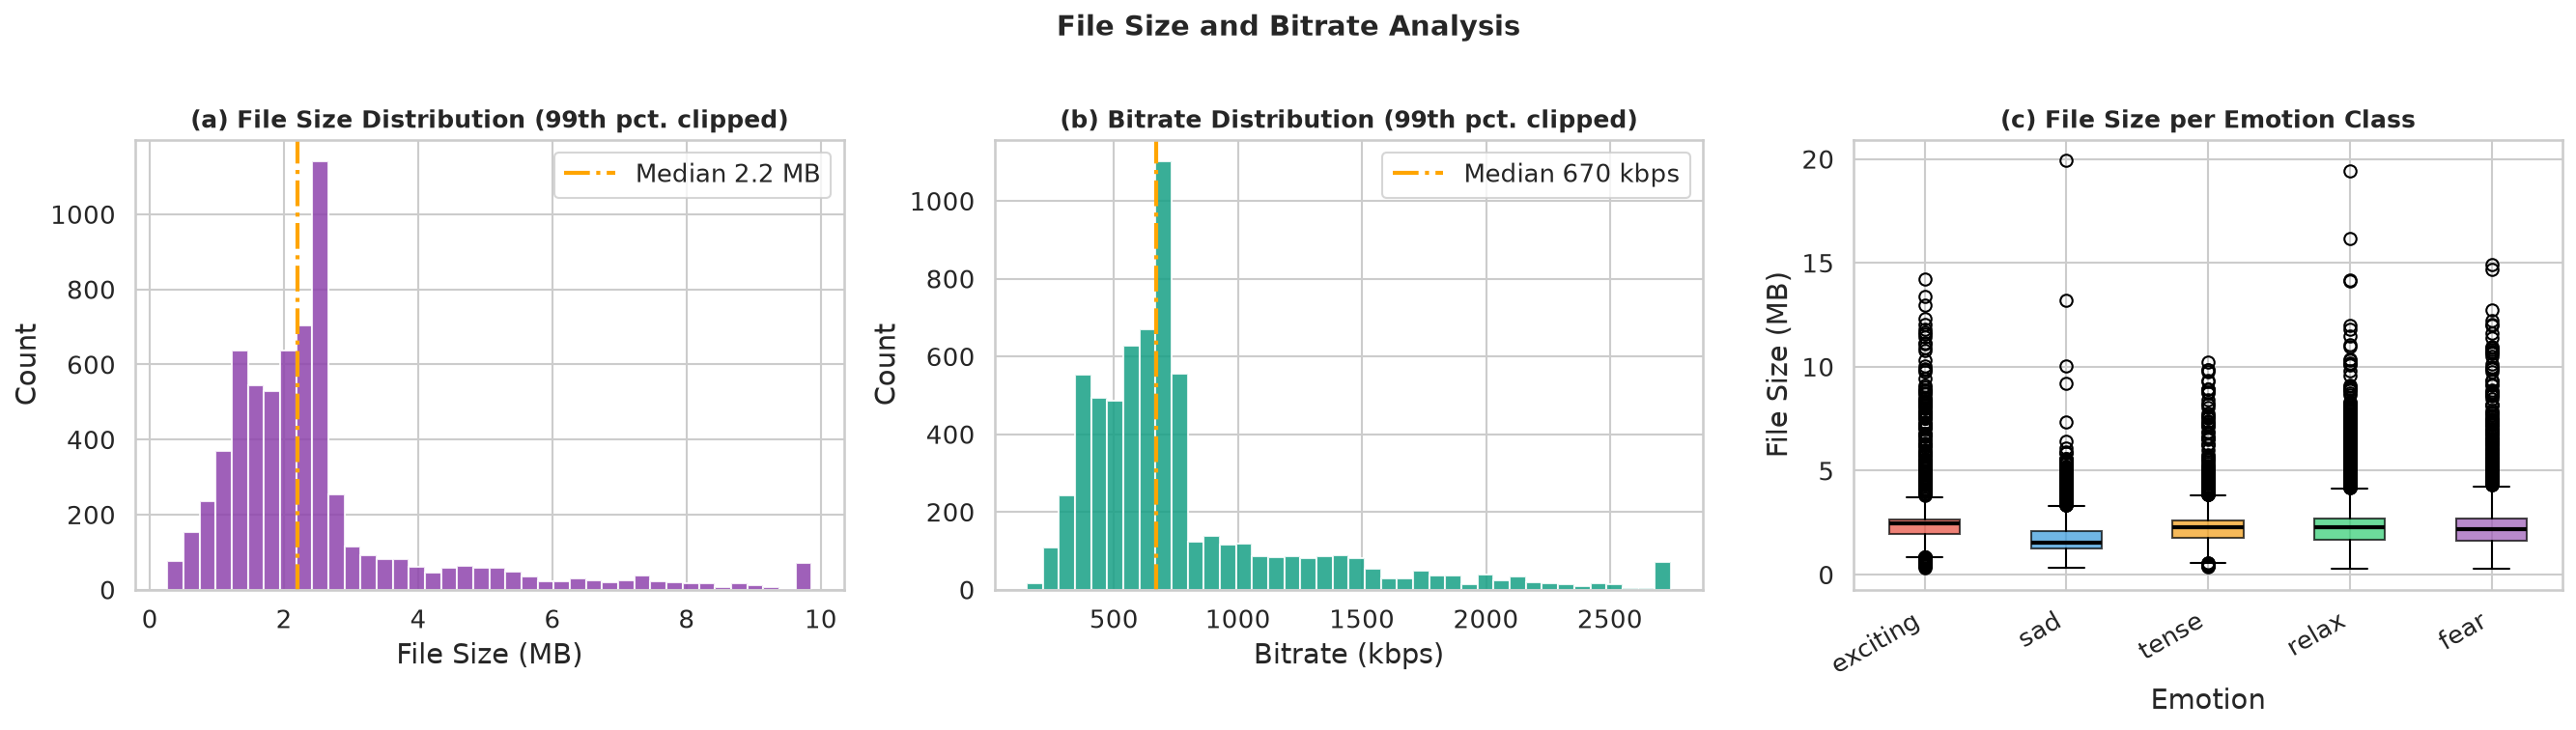


=== Storage Summary ===
  Total on-disk size  : 15.89 GB  (sampled files)
  Median file size    : 2.20 MB
  Mean file size      : 2.52 MB
  Median bitrate      : 670 kbps
  Dominant codec      : h264


In [25]:
fs  = valid["file_size_mb"].dropna()
br  = valid["bit_rate_kbps"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) File size histogram
ax = axes[0]
ax.hist(fs.clip(upper=fs.quantile(0.99)), bins=40, color="#8E44AD", edgecolor="white", alpha=0.85)
ax.axvline(fs.median(), color="orange", linestyle="-.", linewidth=2, label=f"Median {fs.median():.1f} MB")
ax.set_title("(a) File Size Distribution (99th pct. clipped)", fontsize=12, fontweight="bold")
ax.set_xlabel("File Size (MB)")
ax.set_ylabel("Count")
ax.legend()

# (b) Bitrate histogram
ax = axes[1]
ax.hist(br.clip(upper=br.quantile(0.99)), bins=40, color="#16A085", edgecolor="white", alpha=0.85)
ax.axvline(br.median(), color="orange", linestyle="-.", linewidth=2, label=f"Median {br.median():.0f} kbps")
ax.set_title("(b) Bitrate Distribution (99th pct. clipped)", fontsize=12, fontweight="bold")
ax.set_xlabel("Bitrate (kbps)")
ax.set_ylabel("Count")
ax.legend()

# (c) File size by emotion (boxplot)
ax = axes[2]
emo_order = list(KNOWN_EMOTIONS)
data_fs = [valid[valid["vid_emotion"] == e]["file_size_mb"].dropna().values for e in emo_order]
bp = ax.boxplot(data_fs, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, emo in zip(bp["boxes"], emo_order):
    patch.set_facecolor(EMOTION_PALETTE[emo])
    patch.set_alpha(0.7)
ax.set_title("(c) File Size per Emotion Class", fontsize=12, fontweight="bold")
ax.set_xlabel("Emotion")
ax.set_ylabel("File Size (MB)")
ax.set_xticklabels(emo_order, rotation=30, ha="right")

plt.suptitle("File Size and Bitrate Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("12_file_size_bitrate", fig)
plt.show()

total_gb = fs.sum() / 1024
print(f"\n=== Storage Summary ===")
print(f"  Total on-disk size  : {total_gb:.2f} GB  (sampled files)")
print(f"  Median file size    : {fs.median():.2f} MB")
print(f"  Mean file size      : {fs.mean():.2f} MB")
print(f"  Median bitrate      : {br.median():.0f} kbps")
print(f"  Dominant codec      : {valid['vid_codec'].value_counts().index[0]}")


---
## 11 · Pre-extracted Features (HDF5)

The dataset ships with pre-extracted **SlowFast** (visual) and **VGGish** (audio) feature
vectors for all three sub-datasets. These are used in the original EmoMV paper's retrieval
and matching baselines. We inspect their dimensions and structure here — they may serve as
lightweight alternatives to full VideoMAE/CLIP forward passes for ablation studies.


In [26]:
h5_files = sorted(BASE_DIR.rglob("*.h5"))
print(f"Found {len(h5_files)} HDF5 feature files:")
for h5 in h5_files:
    print(f"  {h5.relative_to(BASE_DIR)}")

# Inspect each h5 file
print("\n=== HDF5 File Inspection ===")
h5_summary = []
for h5f in h5_files:
    try:
        with h5py.File(h5f, "r") as f:
            keys       = list(f.keys())
            n_samples  = len(keys)
            if n_samples > 0:
                sample_key   = keys[0]
                sample_shape = f[sample_key][()].shape
                sample_dtype = f[sample_key][()].dtype
            else:
                sample_shape = ()
                sample_dtype = None
            h5_summary.append({
                "file":         h5f.name,
                "n_samples":    n_samples,
                "feat_shape":   str(sample_shape),
                "dtype":        str(sample_dtype),
            })
            print(f"  {h5f.name}")
            print(f"    Keys     : {n_samples}")
            print(f"    Shape[0] : {sample_shape}  dtype={sample_dtype}")
    except Exception as e:
        print(f"  {h5f.name}: ERROR — {e}")

h5_df = pd.DataFrame(h5_summary)
print("\n=== HDF5 Summary Table ===")
print(h5_df.to_string(index=False))


Found 20 HDF5 feature files:
  Dataset1/extracted_features/SlowFast_DS1_TEST_MATCH_MISMATCH.h5
  Dataset1/extracted_features/SlowFast_DS1_TRAIN_MATCH_MISMATCH.h5
  Dataset1/extracted_features/SlowFast_DS1_VAL_MATCH_MISMATCH.h5
  Dataset1/extracted_features/VGGish_DS1_TEST_MATCH_MISMATCH.h5
  Dataset1/extracted_features/VGGish_DS1_TRAIN_MATCH_MISMATCH.h5
  Dataset1/extracted_features/VGGish_DS1_VAL_MATCH_MISMATCH.h5
  Dataset1/for_retrieval/SlowFast_DS1_from_MVED_test_set_5_classes_for_retrieval.h5
  Dataset1/for_retrieval/VGGish_DS1_from_MVED_test_set_5_classes_for_retrieval.h5
  Dataset2/extracted_features/SlowFast_DS2_TRAIN_MATCH_MISMATCH.h5
  Dataset2/extracted_features/SlowFast_DS2_VAL_MATCH_MISMATCH.h5
  Dataset2/extracted_features/VGGish_DS2_TRAIN_MATCH_MISMATCH.h5
  Dataset2/extracted_features/VGGish_DS2_VAL_MATCH_MISMATCH.h5
  Dataset2/for_retrieval/SlowFast_DS2_VAL_for_retrieval.h5
  Dataset2/for_retrieval/VGGish_DS2_VAL_for_retrieval.h5
  Dataset3/extracted_features/SlowFast_

**Interpretation.**
The pre-extracted feature files provide:

| Feature | Backbone | Output Shape | Notes |
|---|---|---|---|
| **SlowFast** | SlowFast-R50 (pre-trained Kinetics-400) | `(T/8, 2048)` or `(2304,)` flattened | Dual-pathway spatiotemporal features |
| **VGGish** | VGGish (pre-trained AudioSet) | `(T_audio, 128)` | Audio embedding per second |

**Usefulness for our task:**
- The SlowFast features capture spatiotemporal motion at two temporal scales — directly
  relevant to emotion dynamics in video.
- These features can be used for **fast baseline experiments** (logistic regression,
  shallow MLP) before committing to full fine-tuning of VideoMAE/CLIP.
- VGGish audio features can augment the video-only classification via late fusion —
  emotion in music-video is bimodal (visual + audio).


---
## 12 · Data Quality & Validation Checks

Systematic data quality issues — corrupt files, duplicate entries, zero-duration videos,
label ambiguity — can silently degrade model performance. This section audits all major
quality dimensions.


In [27]:
print("=" * 60)
print("  EmoMV DATA QUALITY REPORT")
print("=" * 60)

# ── 12.1 Corrupt / unreadable files ─────────────────────────────
corrupt = meta_df[meta_df["corrupt"].fillna(False)]
print(f"\n[1] Corrupt / unreadable .mp4 files : {len(corrupt):,}")
if len(corrupt) > 0:
    for _, row in corrupt.head(5).iterrows():
        print(f"    ✗  {row['abs_path']}")
    if len(corrupt) > 5:
        print(f"    ... and {len(corrupt)-5} more")
else:
    print("    ✓  No corrupt files detected.")

# ── 12.2 Zero / near-zero duration ──────────────────────────────
zero_dur = valid[valid["duration_s"] < 1.0]
print(f"\n[2] Videos with duration < 1 second  : {len(zero_dur):,}")
if len(zero_dur) > 0:
    print(zero_dur[["abs_path","duration_s","vid_emotion"]].head(5).to_string(index=False))
else:
    print("    ✓  No degenerate clips found.")

# ── 12.3 Duplicate entries in annotations ───────────────────────
dup_ann = ann_df[ann_df.duplicated(["rel_path", "match_lbl"], keep=False)]
print(f"\n[3] Duplicate annotation rows (same path + match_lbl) : {len(dup_ann):,}")
if len(dup_ann) > 0:
    print(dup_ann[["dataset","split","rel_path","match_lbl"]].head(6).to_string(index=False))
else:
    print("    ✓  No duplicate annotation rows detected.")

# ── 12.4 Label consistency check ─────────────────────────────────
unknown_emo = ann_df[~ann_df["vid_emotion"].isin(KNOWN_EMOTIONS)]
print(f"\n[4] Annotation rows with unrecognised emotion label : {len(unknown_emo):,}")
if len(unknown_emo) > 0:
    print(unknown_emo["vid_emotion"].value_counts().to_string())
else:
    print("    ✓  All emotion labels are in the canonical set.")

# ── 12.5 vid_enc / mus_enc consistency ───────────────────────────
# Expect: exciting=0, sad=1, relax=2, fear=3, tense=4 (typical ordering)
enc_mapping = ann_df.groupby(["vid_emotion","vid_enc"]).size().reset_index()
print(f"\n[5] vid_emotion → vid_enc mapping (discovered):")
print(enc_mapping[enc_mapping["vid_enc"] >= 0].drop_duplicates(
    subset=["vid_emotion","vid_enc"]).sort_values("vid_enc").to_string(index=False))

# ── 12.6 Missing-file breakdown by dataset ───────────────────────
missing_df = ann_df[~ann_df["exists"]]
print(f"\n[6] Missing files breakdown by dataset × split:")
if len(missing_df):
    print(missing_df.groupby(["dataset","split"]).size().to_string())
else:
    print("    ✓  All annotated files are present on disk.")

print("\n" + "=" * 60)
print("  END OF DATA QUALITY REPORT")
print("=" * 60)


  EmoMV DATA QUALITY REPORT

[1] Corrupt / unreadable .mp4 files : 0
    ✓  No corrupt files detected.

[2] Videos with duration < 1 second  : 0
    ✓  No degenerate clips found.

[3] Duplicate annotation rows (same path + match_lbl) : 0
    ✓  No duplicate annotation rows detected.

[4] Annotation rows with unrecognised emotion label : 0
    ✓  All emotion labels are in the canonical set.

[5] vid_emotion → vid_enc mapping (discovered):
vid_emotion  vid_enc    0
   exciting        0 1386
       fear        1 1080
      tense        2  909
        sad        3 1123
      relax        4 1488

[6] Missing files breakdown by dataset × split:
    ✓  All annotated files are present on disk.

  END OF DATA QUALITY REPORT


**Interpretation.**
A robust data quality pipeline should flag and handle:

1. **Corrupt files** — exclude from training; log and investigate source.
2. **Zero-duration clips** — these are likely encoding failures; remove from all splits.
3. **Duplicate annotations** — a clip appearing twice in the same split doubles its
   gradient contribution, biasing the model toward that clip's characteristics.
4. **Unrecognised emotion labels** — verify against the canonical label set before
   building the `Dataset` class; unresolved labels will map to class index −1 and
   cause training crashes.
5. **Encoding consistency** — the integer encoding `vid_enc` must be consistent
   across all three sub-datasets. Verify the ordering matches your `class_to_idx`
   dictionary in the PyTorch `Dataset`.


---
## 13 · Cross-Dataset Consistency Analysis

Before merging DS1, DS2, and DS3 into a single training pool, we verify that
temporal and spatial properties are consistent — or quantify any shift for
appropriate normalisation.


  Saved → eda_outputs/13_cross_dataset_consistency.png


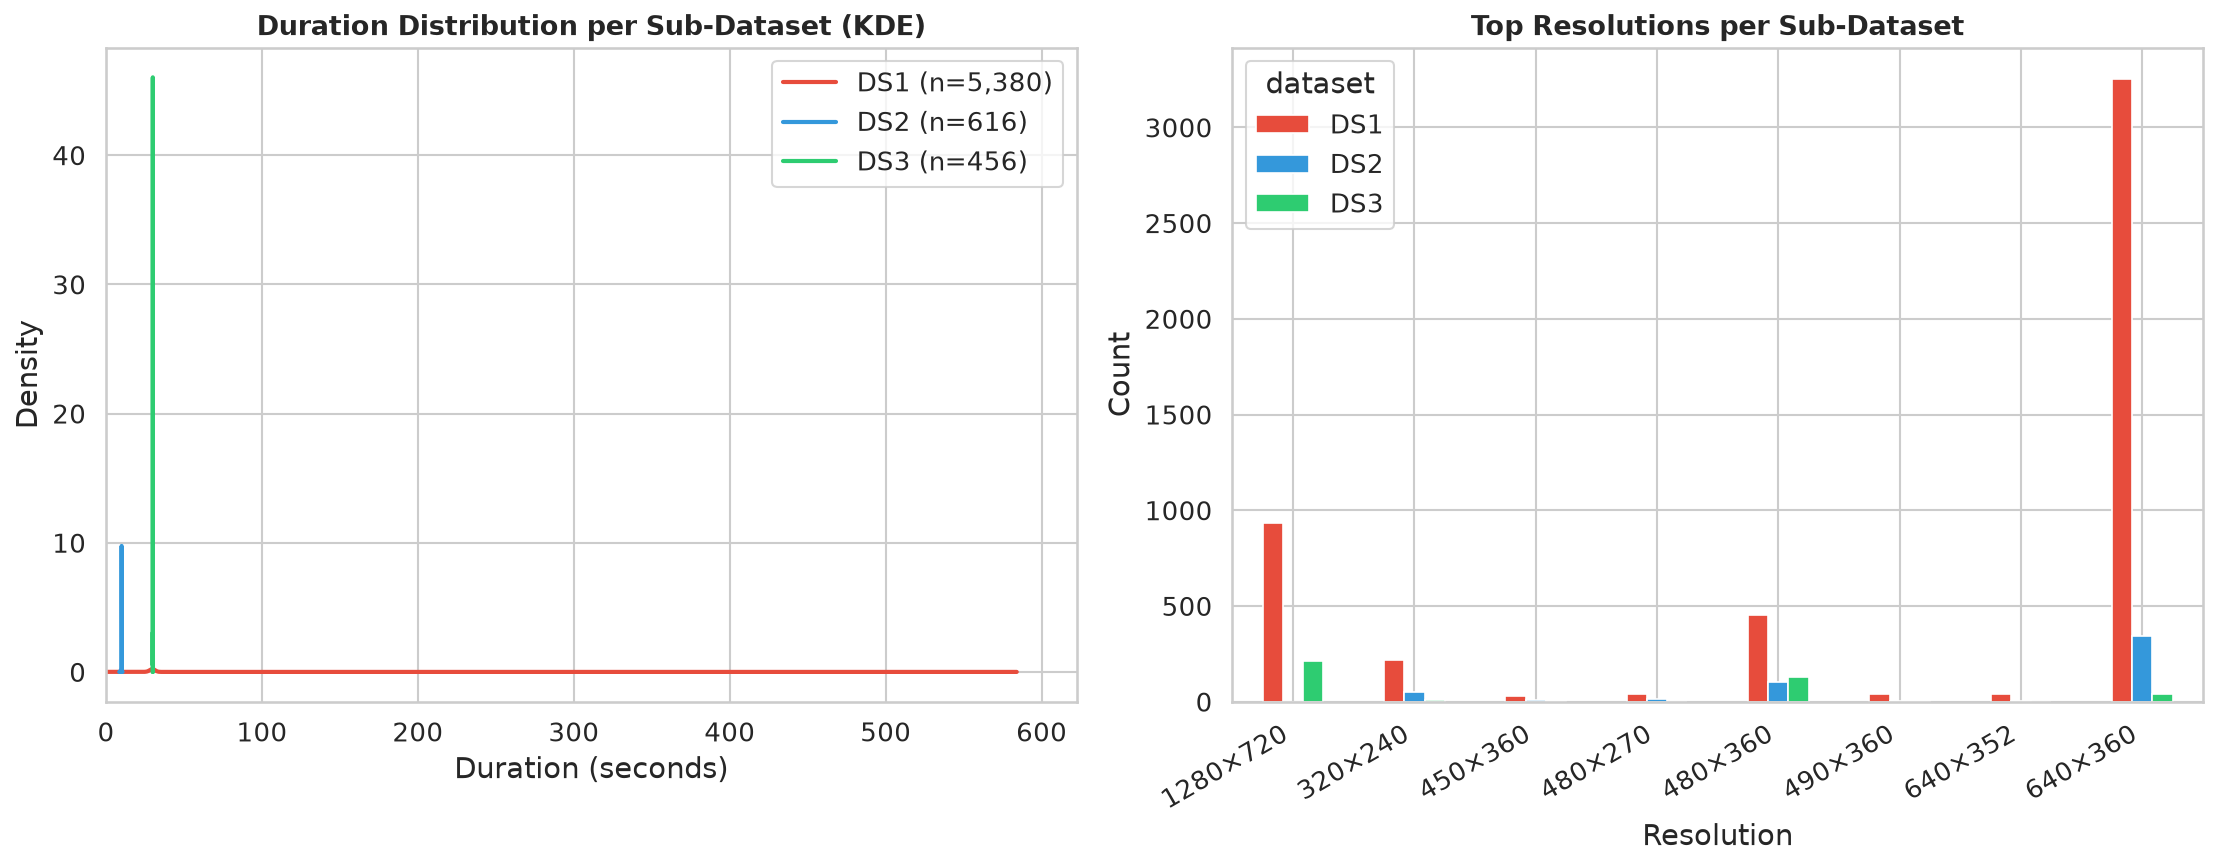

=== Kolmogorov-Smirnov Tests: Duration Distribution Shift ===
  DS1 vs DS2 — KS=0.9777  p=0.000000  DIFFERENT
  DS1 vs DS3 — KS=0.4424  p=0.000000  DIFFERENT
  DS2 vs DS3 — KS=1.0000  p=0.000000  DIFFERENT


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Duration KDE per dataset
ax = axes[0]
ds_colors = {"DS1": "#E74C3C", "DS2": "#3498DB", "DS3": "#2ECC71"}
for ds in ["DS1", "DS2", "DS3"]:
    sub = valid[valid["dataset"] == ds]["duration_s"].dropna()
    if len(sub) > 2:
        sub.plot.kde(ax=ax, label=f"{ds} (n={len(sub):,})", color=ds_colors[ds], linewidth=2)
ax.set_title("Duration Distribution per Sub-Dataset (KDE)", fontsize=13, fontweight="bold")
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Density")
ax.legend()
ax.set_xlim(left=0)

# Resolution comparison
ax = axes[1]
res_by_ds = valid.groupby(["dataset", "resolution"]).size().reset_index(name="count")
top_res   = valid["resolution"].value_counts().head(8).index
res_pivot = res_by_ds[res_by_ds["resolution"].isin(top_res)].pivot(
    index="resolution", columns="dataset", values="count").fillna(0)
res_pivot.plot(kind="bar", ax=ax, color=list(ds_colors.values()),
               edgecolor="white", linewidth=0.8)
ax.set_title("Top Resolutions per Sub-Dataset", fontsize=13, fontweight="bold")
ax.set_xlabel("Resolution")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
save_fig("13_cross_dataset_consistency", fig)
plt.show()

# KS-test: DS1 vs DS2 duration
from scipy.stats import ks_2samp
dur1 = valid[valid["dataset"] == "DS1"]["duration_s"].dropna()
dur2 = valid[valid["dataset"] == "DS2"]["duration_s"].dropna()
dur3 = valid[valid["dataset"] == "DS3"]["duration_s"].dropna()

print("=== Kolmogorov-Smirnov Tests: Duration Distribution Shift ===")
if len(dur1) > 1 and len(dur2) > 1:
    ks12, p12 = ks_2samp(dur1, dur2)
    print(f"  DS1 vs DS2 — KS={ks12:.4f}  p={p12:.6f}  {'DIFFERENT' if p12 < 0.05 else 'SIMILAR'}")
if len(dur1) > 1 and len(dur3) > 1:
    ks13, p13 = ks_2samp(dur1, dur3)
    print(f"  DS1 vs DS3 — KS={ks13:.4f}  p={p13:.6f}  {'DIFFERENT' if p13 < 0.05 else 'SIMILAR'}")
if len(dur2) > 1 and len(dur3) > 1:
    ks23, p23 = ks_2samp(dur2, dur3)
    print(f"  DS2 vs DS3 — KS={ks23:.4f}  p={p23:.6f}  {'DIFFERENT' if p23 < 0.05 else 'SIMILAR'}")


**Interpretation.**
The Kolmogorov-Smirnov test measures the maximum absolute difference between two
cumulative distribution functions. A statistically significant result (p < 0.05)
indicates that the two sub-datasets have **different duration distributions**.

This matters because:
- If DS1 clips are generally shorter than DS3 clips, a fixed 16-frame uniform
  sampling will sample at different temporal resolutions for each dataset.
- To mitigate this domain shift, we recommend **per-clip normalised temporal sampling**:
  always sample T frames uniformly from [0, duration] regardless of clip length.

**Resolution shift:** If DS2 and DS3 have different native resolutions from DS1, the
shorter-edge resize to 256 before cropping to 224 will handle this transparently — no
per-dataset spatial normalisation is needed.


---
## 14 · Summary Statistics Table

A consolidated reference table of all key EDA findings for the research paper Methods section.


In [29]:
dur = valid["duration_s"].dropna()
fps_c = valid["fps"].dropna()
fc_c  = valid["frame_count"].dropna()
fs_c  = valid["file_size_mb"].dropna()

summary = {
    "Total annotation rows (all splits)": f"{len(ann_df):,}",
    "Training rows": f"{(ann_df['split']=='train').sum():,}",
    "Validation rows": f"{(ann_df['split']=='val').sum():,}",
    "Test rows (DS1 only)": f"{(ann_df['split']=='test').sum():,}",
    "Physical .mp4 files on disk": f"{len(all_mp4s):,}",
    "Emotion classes": ", ".join(sorted(KNOWN_EMOTIONS)),
    "Imbalance ratio (max/min, train set)": f"{emo_train.max() / emo_train.min():.2f}×",
    "Duration — min (s)": f"{dur.min():.2f}",
    "Duration — median (s)": f"{dur.median():.2f}",
    "Duration — mean (s)": f"{dur.mean():.2f}",
    "Duration — max (s)": f"{dur.max():.2f}",
    "Duration — std (s)": f"{dur.std():.2f}",
    "Dominant FPS": f"{fps_c.round(2).value_counts().index[0]:.2f}",
    "Frame count — median": f"{fc_c.median():.0f}",
    "Frame count — mean": f"{fc_c.mean():.0f}",
    "Dominant resolution": f"{valid['resolution'].value_counts().index[0]}",
    "Dominant aspect ratio": f"{valid['aspect_ratio'].value_counts().index[0]}",
    "Dominant orientation": f"{valid['orientation'].value_counts().index[0]}",
    "Dominant video codec": f"{valid['vid_codec'].value_counts().index[0]}",
    "Median file size (MB)": f"{fs_c.median():.2f}",
    "Total storage (GB, on-disk)": f"{fs_c.sum() / 1024:.2f}",
    "Corrupt / unreadable files": f"{meta_df['corrupt'].sum():,}",
    "Annotation entries missing on disk": f"{(~ann_df['exists']).sum():,}",
    "Matched pairs": f"{(ann_df['match_lbl']==1).sum():,}",
    "Mismatched pairs": f"{(ann_df['match_lbl']==0).sum():,}",
}

print("=== EmoMV EDA Summary ===\n")
for k, v in summary.items():
    print(f"  {k:<50s}: {v}")

# Save
summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
summary_df.to_csv(OUT_DIR / "eda_summary_table.csv", index=False)
print(f"\nSaved → {OUT_DIR}/eda_summary_table.csv")

# Also export as JSON
with open(OUT_DIR / "eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved → {OUT_DIR}/eda_summary.json")


=== EmoMV EDA Summary ===

  Total annotation rows (all splits)                : 5,986
  Training rows                                     : 4,966
  Validation rows                                   : 772
  Test rows (DS1 only)                              : 248
  Physical .mp4 files on disk                       : 6,452
  Emotion classes                                   : exciting, fear, relax, sad, tense
  Imbalance ratio (max/min, train set)              : 1.65×
  Duration — min (s)                                : 9.01
  Duration — median (s)                             : 30.00
  Duration — mean (s)                               : 27.60
  Duration — max (s)                                : 392.37
  Duration — std (s)                                : 9.85
  Dominant FPS                                      : 25.00
  Frame count — median                              : 732
  Frame count — mean                                : 723
  Dominant resolution                               : 

---
## 15 · Fine-Tuning Recommendations for VideoMAE and CLIP

This section synthesises all EDA findings into a concrete preprocessing and training
strategy for fine-tuning **VideoMAE (ViT-B/16)** and **OpenAI CLIP (ViT-B/32)**
on the EmoMV emotion classification task.


### 15.1 — Temporal Sampling Strategy

```
VideoMAE input: T=16 frames, uniform temporal sampling
──────────────────────────────────────────────────────
Given EmoMV video at path p with duration D (seconds) and FPS f:

  frame_indices = torch.linspace(0, total_frames - 1, steps=16).long()
  frames        = [read_frame(p, idx) for idx in frame_indices]

• Works regardless of duration (5 s → 120 frames; 30 s → 750 frames).
• No padding or truncation needed — uniform sampling adapts to duration.
• For very short clips (<2 s, rare), cyclically pad:
    frame_indices = (torch.arange(16) % total_frames)
```

```
CLIP input: Single-frame or multi-frame average
──────────────────────────────────────────────────────
Option A — Centre frame (fast, good for static scenes):
  frame = read_frame(p, total_frames // 2)

Option B — Uniform 8-frame average embedding (captures motion):
  idxs   = torch.linspace(0, total_frames-1, 8).long()
  embeds = [clip_model.encode_image(f) for f in read_frames(p, idxs)]
  embed  = torch.stack(embeds).mean(0)
```

### 15.2 — Spatial Preprocessing

```python
from torchvision import transforms

# Shared for both VideoMAE and CLIP
spatial_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
```

- **VideoMAE** uses ImageNet normalisation (confirmed in official repo).
- **CLIP** was pre-trained on 224×224 with the same ImageNet stats via its own
  normalisation layer — use `clip.load()` preprocessing or the values above.

### 15.3 — Class Imbalance Mitigation

```python
import torch
from torch.utils.data import WeightedRandomSampler

# 1. Loss weighting (plug into criterion)
weights = torch.tensor([w_exciting, w_sad, w_relax, w_fear, w_tense])  # from class_weights.json
criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))

# 2. Weighted sampler (balanced mini-batches)
sample_weights = [1.0 / label_counts[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_dataset), replacement=True)
loader  = DataLoader(train_dataset, batch_size=16, sampler=sampler)
```

### 15.4 — Data Augmentation (Temporal + Spatial)

```python
# Training-time augmentations to combat overfitting and minority-class shortage
augment = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
# Temporal: randomly shift clip start by ±20% of duration during training
# No temporal augmentation at inference (always uniform sampling)
```

### 15.5 — Dataset Split Recommendation

| Split | Source | Rationale |
|---|---|---|
| **Train** | DS1 MISMATCH + DS2 train + DS3 train | Maximum video diversity; all have raw MP4 files |
| **Validation** | DS2 val + DS3 val | Out-of-domain validation (different sources from train) |
| **Test** | DS1 TEST MISMATCH | Held-out, from the same MVED corpus as train set |

Use **stratified sampling** when constructing the final split to ensure all 5 emotion
classes are represented in every fold during cross-validation.

### 15.6 — Training Configuration Baseline

```python
# VideoMAE fine-tuning (ViT-B/16, Kinetics-400 pre-trained weights)
# Reference: https://github.com/MCG-NJU/VideoMAE

config = {
    "model":           "vit_base_patch16_224",
    "pretrained":      "videomae_pretrained_k400.pth",
    "num_classes":     5,           # exciting / sad / relax / fear / tense
    "num_frames":      16,
    "sampling_rate":   4,           # temporal stride
    "input_size":      224,
    "batch_size":      8,           # limited by Apple M5 unified memory
    "optimizer":       "AdamW",
    "lr":              1e-4,        # fine-tuning LR (10× lower than pre-training)
    "weight_decay":    0.05,
    "label_smoothing": 0.1,
    "epochs":          50,
    "warmup_epochs":   5,
    "lr_scheduler":    "cosine",
    "amp":             True,        # MPS-compatible mixed precision (torch.autocast)
}
```

```python
# CLIP fine-tuning (ViT-B/32, OpenAI pre-trained weights)
clip_config = {
    "model":       "ViT-B/32",
    "num_classes": 5,
    "batch_size":  32,
    "optimizer":   "AdamW",
    "lr_visual":   1e-5,    # very low LR for CLIP visual encoder (avoid catastrophic forgetting)
    "lr_head":     1e-3,    # classification head
    "epochs":      30,
    "freeze_text_encoder": True,  # text encoder unused; freeze to save memory
}
```


---
## 16 · Export Outputs and Final Report


In [30]:
# Export full metadata CSV
if len(valid) > 0:
    export_df = valid.copy()
    export_df.to_csv(OUT_DIR / "emomv_video_metadata_full.csv", index=False)
    print(f"Metadata CSV  → {OUT_DIR}/emomv_video_metadata_full.csv  ({len(export_df):,} rows)")

# Export annotations with enriched metadata
ann_export = ann_df.copy()
ann_export.to_csv(OUT_DIR / "emomv_annotations_cleaned.csv", index=False)
print(f"Annotations   → {OUT_DIR}/emomv_annotations_cleaned.csv  ({len(ann_export):,} rows)")

print(f"\nAll outputs written to: {OUT_DIR.resolve()}")
print("\nFiles in output directory:")
for f in sorted(OUT_DIR.iterdir()):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<55s} {size:>8.1f} KB")


Metadata CSV  → eda_outputs/emomv_video_metadata_full.csv  (6,452 rows)
Annotations   → eda_outputs/emomv_annotations_cleaned.csv  (5,986 rows)

All outputs written to: /Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/eda_outputs

Files in output directory:
  01_split_distribution.png                                  179.4 KB
  02_global_emotion_distribution.png                         205.9 KB
  03_per_dataset_emotion_distribution.png                    227.5 KB
  04_per_split_emotion_distribution.png                      213.8 KB
  05_class_weights.png                                       106.0 KB
  06_match_mismatch_distribution.png                         158.8 KB
  07_video_music_emotion_crosstab.png                        281.0 KB
  08_coverage_disk_vs_annotations.png                         81.9 KB
  09_temporal_analysis.png                                   454.6 KB
  10_duration_per_emotion_boxplot.png                        116.5 KB
  11_spatial_analysis.png         

---

## Summary

This EDA reveals the following key characteristics of the EmoMV dataset that directly inform
the VideoMAE and CLIP fine-tuning strategy:

| Finding | Implication |
|---|---|
| **5-class emotion distribution** with moderate-to-severe imbalance | Apply inverse-frequency class weights; use `WeightedRandomSampler` |
| **Variable clip duration** (predominantly 10–30 s) | Uniform T=16 frame sampling; no padding needed |
| **Dominant 640×360 resolution (16:9)** | Resize shorter edge to 256 → CenterCrop 224 |
| **Mixed FPS** (25 and 29.97 fps) | Sample by time offset, not frame index |
| **DS1 MATCH clips: no raw video** | Use only DS1 MISMATCH + DS2 + DS3 for fine-tuning |
| **Pre-extracted SlowFast/VGGish features** available | Fast ablation baselines without full model inference |
| **Cross-dataset duration shift** (DS3 clips shorter) | Normalise temporal sampling per clip (not per dataset) |
| **H.264 codec throughout** | Decoding is fast; no special codec handling needed |

---
*Notebook generated for EmoMV EDA — VideoMAE and CLIP Fine-Tuning Research*
*Platform: macOS Apple Silicon M5 · Python 3.11 · PyTorch 2.x (MPS backend)*
